# Credit Default Risk Prediction

## Data Loading

In [96]:
import json
import os
import platform
import random
import time
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import sklearn
import xgboost as xgb

from IPython.display import display
from google.colab import drive, files
from scipy import sparse
from scipy.stats import kendalltau, loguniform
from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_predict,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)
print("LightGBM:", lgb.__version__)
print("SHAP:", shap.__version__)


Python: 3.13.15
pandas: 2.2.3
scikit-learn: 1.6.1
XGBoost: 3.4.1
LightGBM: 4.6.0
SHAP: 0.52.0


In [97]:
# Mount Google Drive and create a persistent project structure.
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/Credit_Risk_Prediction")
DATA_DIR = PROJECT_DIR / "dataset"
OUTPUT_ROOT = PROJECT_DIR / "outputs"
COMPARISON_DIR = OUTPUT_ROOT / "cross_experiment_comparison"

OUTPUT_DIRS = {
    "UCI_Credit_Card": {
        "root": OUTPUT_ROOT / "uci_primary",
        "processed": OUTPUT_ROOT / "uci_primary" / "processed",
        "models": OUTPUT_ROOT / "uci_primary" / "models",
        "results": OUTPUT_ROOT / "uci_primary" / "results",
        "figures": OUTPUT_ROOT / "uci_primary" / "figures",
        "shap": OUTPUT_ROOT / "uci_primary" / "shap",
    },
    "German_Credit": {
        "root": OUTPUT_ROOT / "german_replication",
        "processed": OUTPUT_ROOT / "german_replication" / "processed",
        "models": OUTPUT_ROOT / "german_replication" / "models",
        "results": OUTPUT_ROOT / "german_replication" / "results",
        "figures": OUTPUT_ROOT / "german_replication" / "figures",
        "shap": OUTPUT_ROOT / "german_replication" / "shap",
    },
}

for folder in [PROJECT_DIR, DATA_DIR, OUTPUT_ROOT, COMPARISON_DIR]:
    folder.mkdir(parents=True, exist_ok=True) #create any missing parent folders
    #does not raise an error if the folder already exists
for group in OUTPUT_DIRS.values():
   #handles folders stored inside a nested dict
   #retrieves each dataset group, eg: uci and german dict
    for folder in group.values(): #retrieve every folder path inside that group
        folder.mkdir(parents=True, exist_ok=True) #create each foleder

FAST_MODE = True
RUN_ROBUSTNESS = True
RUN_HEAVY_LEARNING_CURVES = False
TEST_SIZE = 0.20
CV_SPLITS = 3 if FAST_MODE else 5
SEARCH_ITERATIONS = 8 if FAST_MODE else 25
PRIMARY_METRIC = "roc_auc"

print(f"Project directory: {PROJECT_DIR}")
print(
    f"FAST_MODE={FAST_MODE}, CV_SPLITS={CV_SPLITS}, "
    f"SEARCH_ITERATIONS={SEARCH_ITERATIONS}"
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/Credit_Risk_Prediction
FAST_MODE=True, CV_SPLITS=3, SEARCH_ITERATIONS=8


In [ ]:
def locate_or_upload(candidates, requested_name):
    # Find a dataset in Drive or request a local upload and persist it.
    for candidate in candidates:
        path = DATA_DIR / candidate
        if path.exists():
            print(f"Found: {path}")
            return path

    print(f"Missing {requested_name}. Select it in the upload dialog.")
    uploaded = files.upload() #uploaded is a dict
    if not uploaded:
        raise FileNotFoundError(f"No file uploaded for {requested_name}.")

#takes the first uploaded file, save it to DATA_DIR and returns its saved path
#selected name: the file original name, eg: UCI_Credit_Card.csv
#content: the actual file content in bytes
    selected_name, content = next(iter(uploaded.items()))
    destination = DATA_DIR / requested_name
    destination.write_bytes(content)
    print(f"Saved uploaded file to: {destination}")
    return destination


UCI_PATH = locate_or_upload(
    ["UCI_Credit_Card.csv"], #file original name, requested name in this project (standardized)
    "UCI_Credit_Card.csv",
)
GERMAN_PATH = locate_or_upload(["german.data"], "german.data")


Found: /content/drive/MyDrive/Credit_Risk_Prediction/dataset/UCI_Credit_Card.csv
Found: /content/drive/MyDrive/Credit_Risk_Prediction/dataset/german.data


### Target definitions and cleaning decisions

- **UCI:** `default.payment.next.month` is renamed to `default`; `1` already means default. `ID` is removed because it is an identifier. Undocumented/unknown `EDUCATION` codes `0`, `5`, and `6` are consolidated into `other_or_unknown`; `MARRIAGE = 0` is consolidated into `other_or_unknown`. Repayment status remains ordinal because its magnitude represents delay severity.
- **German:** the last field is `credit_class`; `1 = good` and `2 = bad`. It is recoded as `default = 0` and `default = 1`, respectively. Symbolic codes are mapped to human-readable labels using `german.doc` definitions. Its documented cost matrix assigns cost 5 to a bad applicant predicted good (false negative) and cost 1 to a good applicant predicted bad (false positive); a later section tunes this operating threshold using training-only out-of-fold predictions.


### UCI feature dictionary

| Variable(s) | Meaning |
|---|---|
| `ID` | Client identifier; removed before modelling. |
| `LIMIT_BAL` | Granted credit limit in NT dollars, including supplementary/family credit. |
| `SEX` | Gender code (`1 = male`, `2 = female`), mapped to labels. |
| `EDUCATION` | `1 = graduate school`, `2 = university`, `3 = high school`, `4 = other`; codes `0/5/6` are consolidated as unknown/other. |
| `MARRIAGE` | `1 = married`, `2 = single`, `3 = other`; code `0` is consolidated as unknown/other. |
| `AGE` | Age in years. |
| `PAY_0`, `PAY_2`–`PAY_6` | Repayment status from September back to April 2005. Positive values indicate months of delay. Observed non-positive codes are retained as ordered source values. |
| `BILL_AMT1`–`BILL_AMT6` | Monthly bill-statement amounts from September back to April 2005 (NT dollars). |
| `PAY_AMT1`–`PAY_AMT6` | Monthly previous-payment amounts from September back to April 2005 (NT dollars). |
| `default.payment.next.month` | Original binary target (`1 = default`, `0 = non-default`), renamed `default`. |

### German Statlog feature dictionary

| Variable | Type | Meaning |
|---|---|---|
| `checking_status` | Categorical | Status/balance range of the existing checking account. |
| `duration_months` | Numeric | Credit duration in months. |
| `credit_history` | Categorical | Past and current credit repayment history. |
| `purpose` | Categorical | Purpose of the credit (e.g., car, furniture, education, business). |
| `credit_amount` | Numeric | Requested credit amount in Deutsche Marks. |
| `savings_status` | Categorical | Savings/bond balance range or no known savings. |
| `employment` | Categorical | Present employment-duration band. |
| `installment_rate` | Numeric/ordinal | Installment rate as a percentage of disposable income. |
| `personal_status_sex` | Categorical | Combined personal-status and sex code from the source dataset. |
| `other_debtors` | Categorical | None, co-applicant, or guarantor. |
| `residence_since` | Numeric/ordinal | Duration at the present residence. |
| `property` | Categorical | Property/asset category. |
| `age` | Numeric | Age in years. |
| `other_installment_plans` | Categorical | Other installment plan (bank, store, or none). |
| `housing` | Categorical | Rent, own, or free housing. |
| `existing_credits` | Numeric/ordinal | Number of existing credits at the bank. |
| `job` | Categorical | Employment/skill category. |
| `liable_people` | Numeric/ordinal | Number of dependants for whom the applicant provides maintenance. |
| `telephone` | Categorical | Whether a telephone is registered in the applicant's name. |
| `foreign_worker` | Categorical | Foreign-worker status. |
| `credit_class` | Target | Original class (`1 = good`, `2 = bad`), recoded to `default`. |


In [ ]:
GERMAN_COLUMNS = [
    "checking_status", "duration_months", "credit_history", "purpose",
    "credit_amount", "savings_status", "employment", "installment_rate",
    "personal_status_sex", "other_debtors", "residence_since", "property",
    "age", "other_installment_plans", "housing", "existing_credits", "job",
    "liable_people", "telephone", "foreign_worker", "credit_class",
]

GERMAN_CODE_MAPS = {
    "checking_status": {
        "A11": "lt_0", "A12": "0_to_200", "A13": "gte_200", "A14": "none",
    },
    "credit_history": {
        "A30": "no_credit_or_all_paid", "A31": "all_paid_here",
        "A32": "existing_paid_duly", "A33": "delay_in_past",
        "A34": "critical_or_other_credit",
    },
    "purpose": {
        "A40": "new_car", "A41": "used_car", "A42": "furniture_equipment",
        "A43": "radio_tv", "A44": "domestic_appliances", "A45": "repairs",
        "A46": "education", "A47": "vacation", "A48": "retraining",
        "A49": "business", "A410": "other",
    },
    "savings_status": {
        "A61": "lt_100", "A62": "100_to_500", "A63": "500_to_1000",
        "A64": "gte_1000", "A65": "unknown_or_none",
    },
    "employment": {
        "A71": "unemployed", "A72": "lt_1_year", "A73": "1_to_4_years",
        "A74": "4_to_7_years", "A75": "gte_7_years",
    },
    "personal_status_sex": {
        "A91": "male_divorced_separated", "A92": "female_divorced_separated_married",
        "A93": "male_single", "A94": "male_married_widowed", "A95": "female_single",
    },
    "other_debtors": {
        "A101": "none", "A102": "co_applicant", "A103": "guarantor",
    },
    "property": {
        "A121": "real_estate", "A122": "life_insurance_or_savings",
        "A123": "car_or_other", "A124": "unknown_or_none",
    },
    "other_installment_plans": {
        "A141": "bank", "A142": "stores", "A143": "none",
    },
    "housing": {"A151": "rent", "A152": "own", "A153": "free"},
    "job": {
        "A171": "unemployed_unskilled_nonresident", "A172": "unskilled_resident",
        "A173": "skilled_employee", "A174": "management_self_employed_highly_qualified",
    },
    "telephone": {"A191": "none", "A192": "yes"},
    "foreign_worker": {"A201": "yes", "A202": "no"},
}

###UCI Loading Function

In [ ]:
def load_uci(path):
  df = pd.read_csv(path)
  target_col = "default.payment.next.month"

  df = df.copy()
  df = df.rename(columns={target_col: "default"})
  df = df.drop(columns=["ID"])

  df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
  df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})
  df["SEX"] = df["SEX"].map({1: "male", 2: "female"}).fillna("unknown")
  df["EDUCATION"] = df["EDUCATION"].map({
      1: "graduate_school", 2: "university", 3: "high_school", 4: "other_or_unknown"
      }).fillna("other_or_unknown")
  df["MARRIAGE"] = df["MARRIAGE"].map({
      1: "married", 2: "single", 3: "other_or_unknown"
  }).fillna("other_or_unknown")
  df["default"] = pd.to_numeric(df["default"])

  if not set(df["default"].unique()).issubset({0,1}):
    raise ValueError("ICI target must contain only 0 and 1")
  return df

### German Credit Loading Function

In [ ]:
def load_german(path):
  df = pd.read_csv(path, sep=r"\s+", header=None, names=GERMAN_COLUMNS)

  df = df.copy()
  for column, mapping in GERMAN_CODE_MAPS.items():
    unmapped = set(df[column].dropna().unique()).difference(mapping)
    if unmapped:
      raise ValueError(f"Unknown values in {column}: {unmapped}")
    df[column] = df[column].map(mapping)

    df["default"] = df["credit_class"].map({1: 0, 2: 1})
    df["default"] = df["default"].astype(int)
  return df.drop(columns=["credit_class"])


In [ ]:
uci_raw = load_uci(UCI_PATH)
german_raw = load_german(GERMAN_PATH)

print("UCI shape: ", uci_raw.shape)
print("German credit shape: ", german_raw.shape)
display(uci_raw.head())
display(german_raw.head())

UCI shape:  (30000, 24)
German credit shape:  (1000, 21)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,liable_people,telephone,foreign_worker,default
0,lt_0,6,critical_or_other_credit,radio_tv,1169,unknown_or_none,gte_7_years,4,male_single,none,...,real_estate,67,none,own,2,skilled_employee,1,yes,yes,0
1,0_to_200,48,existing_paid_duly,radio_tv,5951,lt_100,1_to_4_years,2,female_divorced_separated_married,none,...,real_estate,22,none,own,1,skilled_employee,1,none,yes,1
2,none,12,critical_or_other_credit,education,2096,lt_100,4_to_7_years,2,male_single,none,...,real_estate,49,none,own,1,unskilled_resident,2,none,yes,0
3,lt_0,42,existing_paid_duly,furniture_equipment,7882,lt_100,4_to_7_years,2,male_single,guarantor,...,life_insurance_or_savings,45,none,free,1,skilled_employee,2,none,yes,0
4,lt_0,24,delay_in_past,new_car,4870,lt_100,1_to_4_years,3,male_single,none,...,unknown_or_none,53,none,free,2,skilled_employee,2,none,yes,1


### Validate row counts, targets and data quality

In [ ]:
def data_quality_summary(df, name):
  return{
      "dataset": name,
      "rows": len(df),
      "predictors": df.shape[1] - 1,
      "missing_cells": int(df.isna().sum().sum()),
      "duplicate_rows": int(df.duplicated().sum()),
      "non_default_n": int((df["default"] == 0). sum()),
      "default_n": int((df["default"] == 1).sum()),
      "default_rate": float(df["default"].mean()),
  }

quality = pd.DataFrame([
    data_quality_summary(uci_raw, "UCI Credit Card"),
    data_quality_summary(german_raw, "German Credit"),
])

display(quality.style.format({"default_rate": "{:.2%}"}))
quality.to_csv(COMPARISON_DIR / "data_quality_summary.csv", index=False)

,dataset,rows,predictors,missing_cells,duplicate_rows,non_default_n,default_n,default_rate
0,UCI Credit Card,30000,23,0,35,23364,6636,22.12%
1,German Credit,1000,20,0,0,700,300,30.00%


## Part A — Primary experiment: UCI Credit Card

UCI represents behavioural scoring: existing cardholders are assessed using six months of
repayment status, bills and previous payments. Its EDA is intentionally presented separately
from the German application-scoring data.


### Plotting Helper

In [ ]:
def save_and_show(path):
  path = Path(path)
  path.parent.mkdir(parents=True, exist_ok=True) #Creates the folder in which the figure will be saved.
  #parent.mkdir is figure/uci
  plt.tight_layout()
  plt.savefig(path, dpi=180, bbox_inches="tight")
  plt.show()
  plt.close()

In [ ]:
from matplotlib.lines import lineStyles
def target_distribution_plot(dataset_name, df):
  out = OUTPUT_DIRS[dataset_name]
  counts = df["default"].value_counts().sort_index()
  fig, ax = plt.subplots(figsize=(6,4))
  bars = ax.bar(
      ["Non-default(0)", "Default(1)"],
      counts.values,
      color=["#4C78A8", "#E67E22"],
      edgecolor="black",
      linewidth=1,
      linestyle="solid"

  )

  total = counts.sum()

  bar_labels = [
      f"{count:,}\n({count / total:.1%})"
      for count in counts.values
  ]

  ax.bar_label(bars, labels=bar_labels, padding=3)
  ax.set_ylim(0, counts.max()*1.2) #add space above bars for labels


  ax.set_title(f"{dataset_name}: Target distribution", fontsize= 12, fontweight="bold")
  ax.set_ylabel("Records", fontsize=12)
  ax.xaxis.grid(False)
  save_and_show(out["figures"] / "target_distribution.png")


In [ ]:
def numeric_distribution_plot(dataset_name, df):
  out = OUTPUT_DIRS[dataset_name]
  numeric = df.select_dtypes(include=np.number).columns.drop("default", errors = "ignore")
  selected = list(numeric[:min(12, len(numeric))])
  df[selected].hist(figsize=(16, 10), bins=30, layout=(3, 4), color="#4C78A8", edgecolor="black", linewidth=1)
  plt.suptitle(f"{dataset_name}: selected numeric distribution", fontsize=16, fontweight="bold")
  save_and_show(out["figures"] / "numeric_distribution.png")

In [ ]:
def correlation_plot(dataset_name, df):
  out = OUTPUT_DIRS[dataset_name]
  numeric = df.select_dtypes(include=np.number).columns.drop("default", errors="ignore")
  corr = df[list(numeric) + ["default"]].corr(method="spearman")
  corr.to_csv(out["results"] / "spearman_correlation.csv")
  plt.figure(figsize=(min(18, 1+0.7 * len(corr)), min(14, 1+0.6 * len(corr))))

  sns.heatmap(
      corr,
      annot=True,
      fmt=".2%",
      annot_kws={"fontsize": 7},
      linecolor="white",
      linewidths=0.3,
      cmap="vlag",
      center=0,
      vmin=-1,
      vmax=1)

  plt.title(f"{dataset_name}: Spearman Correlation", fontsize=16, fontweight="bold")
  save_and_show(out["figures"] / "spearman_correlation.png")

In [ ]:
def categorical_default_rate_plot(dataset_name, df):
  out = OUTPUT_DIRS[dataset_name]
  categorical = df.select_dtypes(exclude=np.number).columns
  if not len(categorical):
    return

  spreads = {
      col: df.groupby(col, observed=False)["default"].mean().pipe(lambda s: s.max() - s.min())
      for col in categorical
   }

  selected = sorted(spreads, key=spreads.get, reverse=True)[:8]
  fig, axes = plt.subplots(len(selected), 1, figsize=(11, 3.3 * len(selected)))
  axes = np.atleast_1d(axes)

  for ax, col in zip(axes, selected):
    rates = df.groupby(col, observed=False)["default"].agg(["mean", "count"]).sort_values("mean")
    #Only category names appear on the y-axis
    category_labels =  rates.index.astype(str)
    sns.barplot(
        x=rates["mean"],
        y=category_labels,
        ax=ax,
        color="#4C78A8",
        linewidth=1,
        edgecolor="black"
    )

    count_labels = [
        f"n = {int(count):,}"
        for count in rates["count"]
    ]

    ax.bar_label(
        ax.containers[0],
        labels=count_labels,
        label_type="edge",
        padding=4,
        fontsize=10
    )


    ax.set_title(col, fontsize=14, fontweight="bold")
    ax.set_xlabel("Default rate")
    ax.set_ylabel("")
  fig.suptitle(f"{dataset_name}: Categorical default rates", y=1.01, fontsize=15, fontweight="bold")
  save_and_show(out["figures"] / "categorical_default_rates.png")



### UCI descriptive statistics and data-quality table

In [ ]:
uci_raw.describe(include="all").T.to_csv(
    OUTPUT_DIRS["UCI_Credit_Card"]["results"] / "descriptive_statistics.csv"
)
pd.DataFrame({
    "missing": uci_raw.isna().sum(),
    "duplicate": uci_raw.nunique(),
}).to_csv(OUTPUT_DIRS["UCI_Credit_Card"]["results"] / "data_quality_by_feature.csv")

display(uci_raw.describe().T)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0
PAY_6,30000.0,-0.291100,1.149988,-2.0,-1.00,0.0,0.00,8.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0


### UCI target distribution

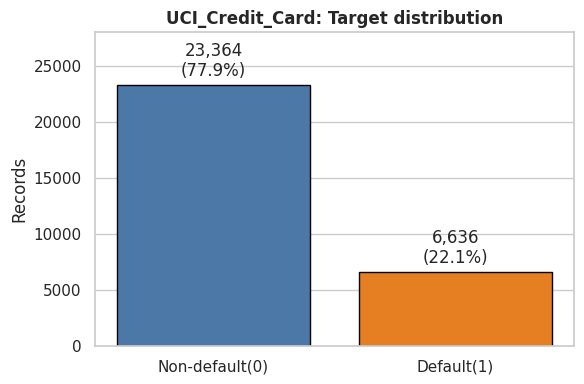

In [ ]:
target_distribution_plot("UCI_Credit_Card", uci_raw)

### UCI numeric distributions

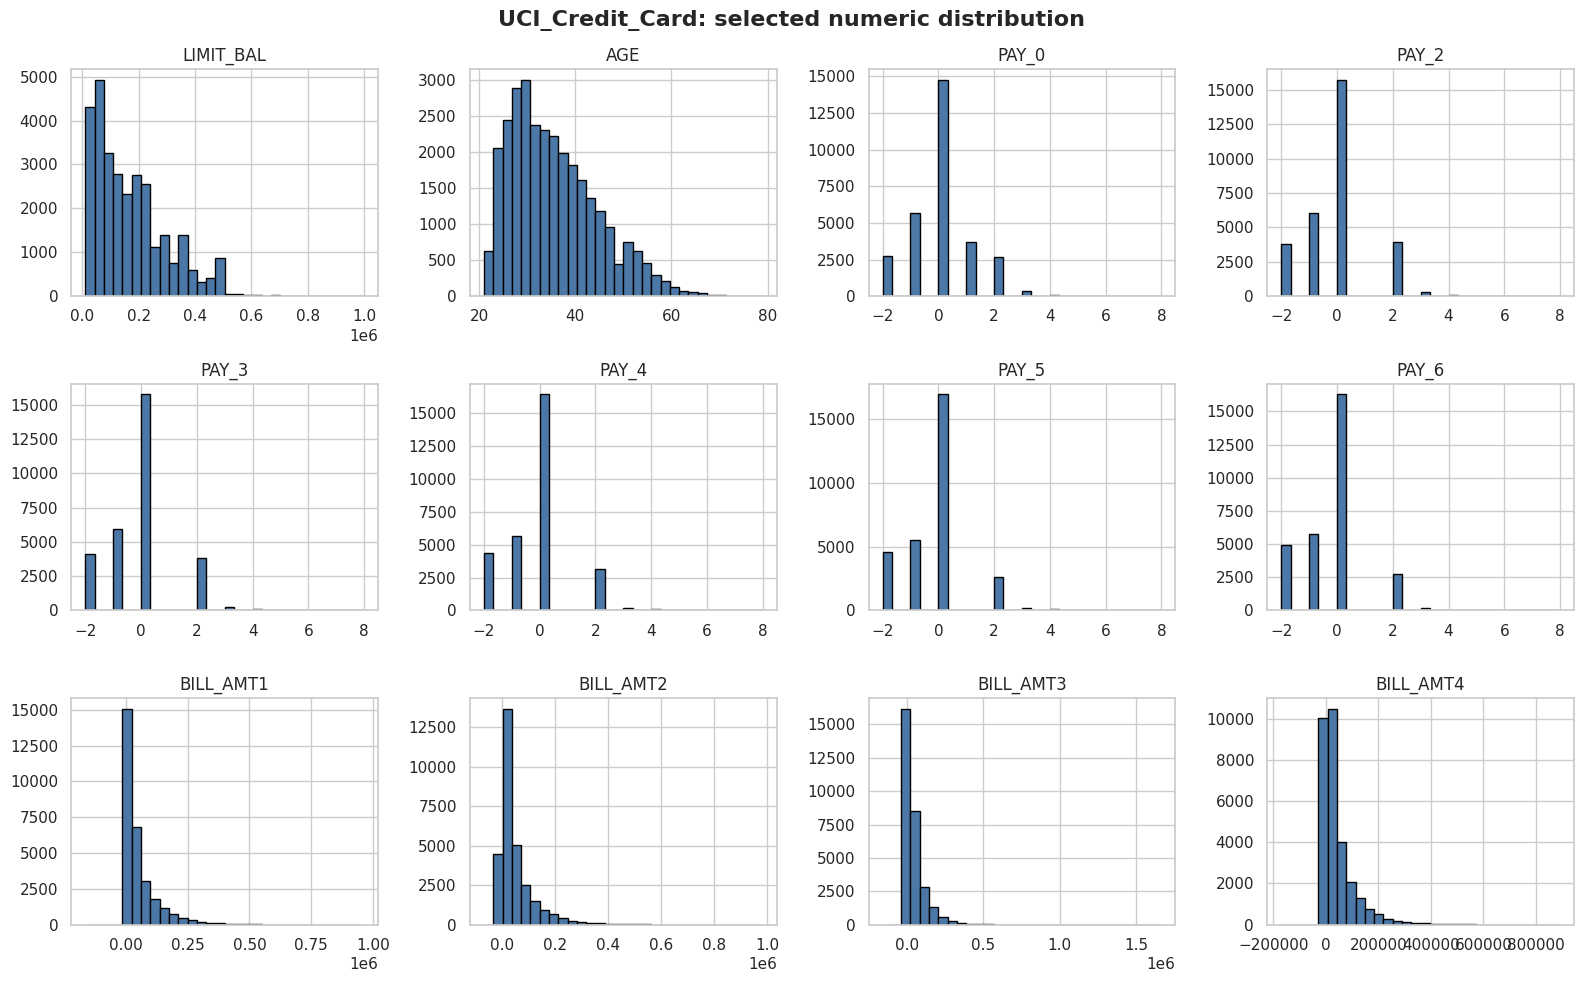

In [ ]:
numeric_distribution_plot("UCI_Credit_Card", uci_raw)

### UCI Spearman correlation

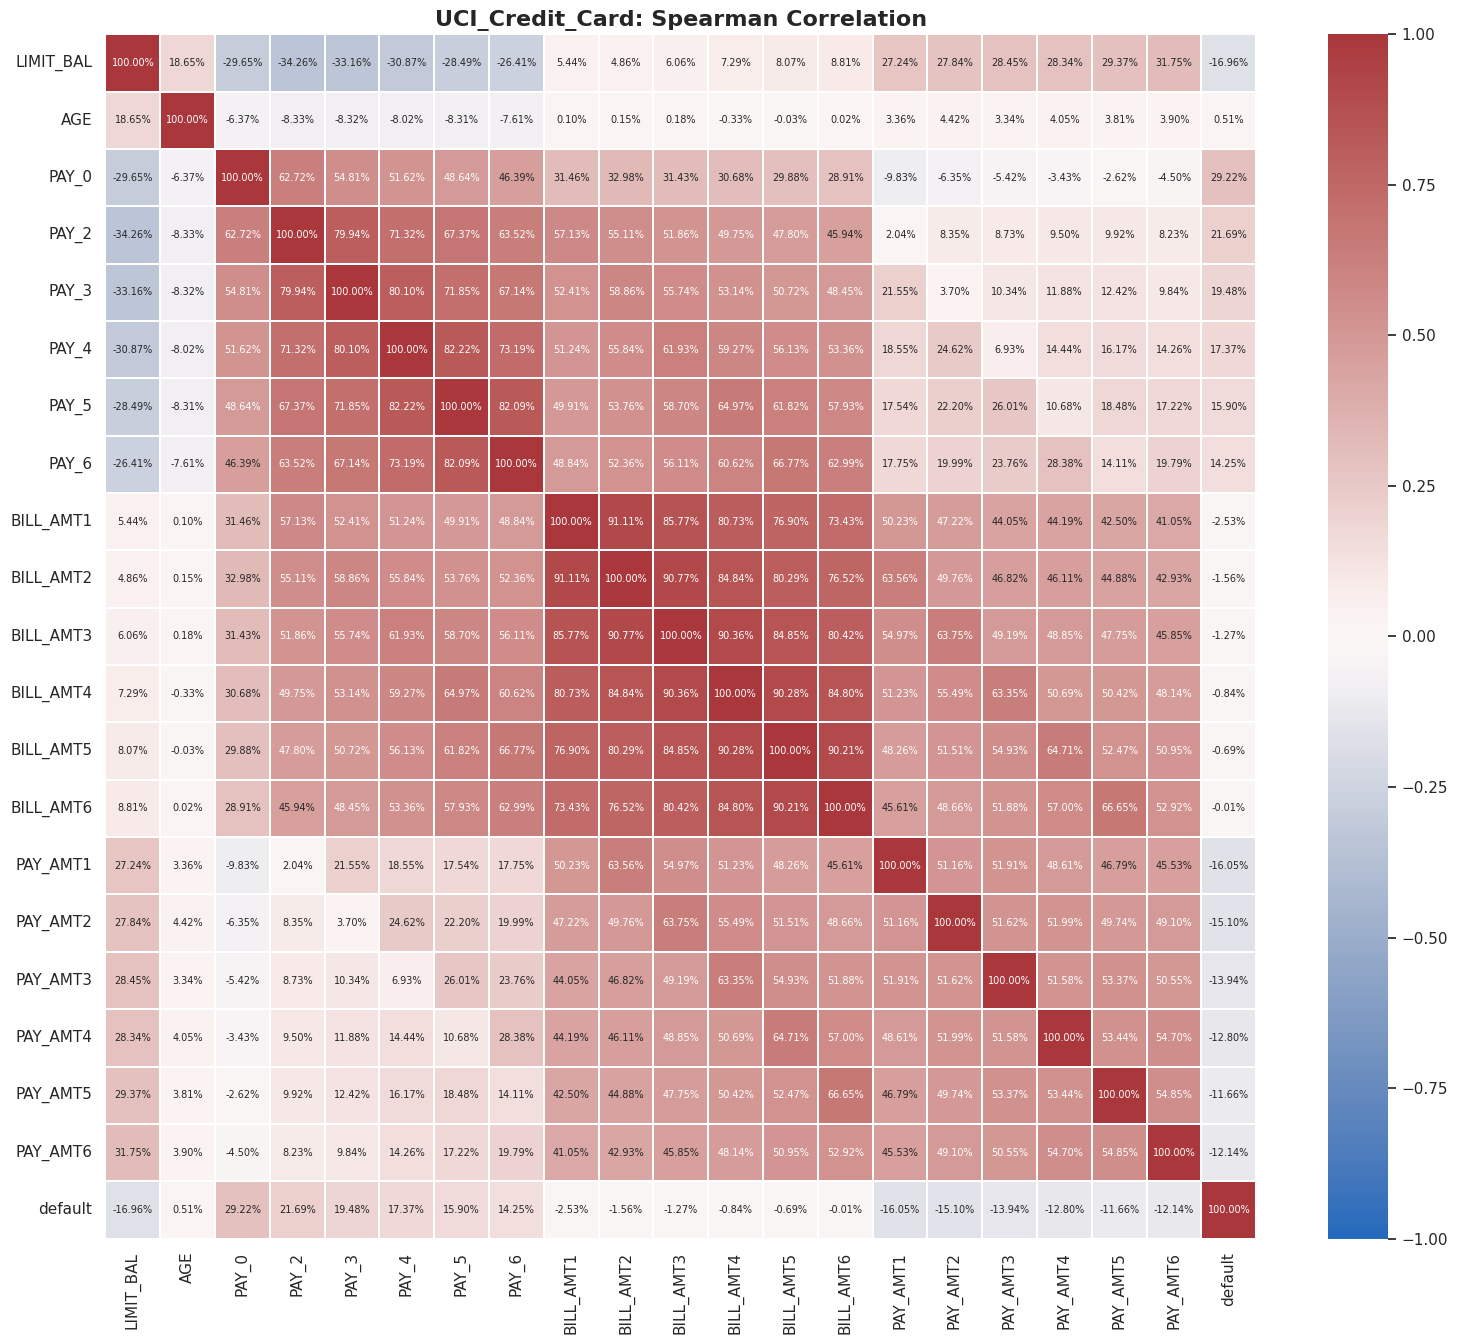

In [ ]:
correlation_plot("UCI_Credit_Card", uci_raw)

### UCI repayment-status analysis

,PAY_0,mean,count
0,-2,0.132294,2759
1,-1,0.167781,5686
2,0,0.128113,14737
3,1,0.339479,3688
4,2,0.691414,2667
5,3,0.757764,322
6,4,0.684211,76
7,5,0.500000,26
8,6,0.545455,11
9,7,0.777778,9


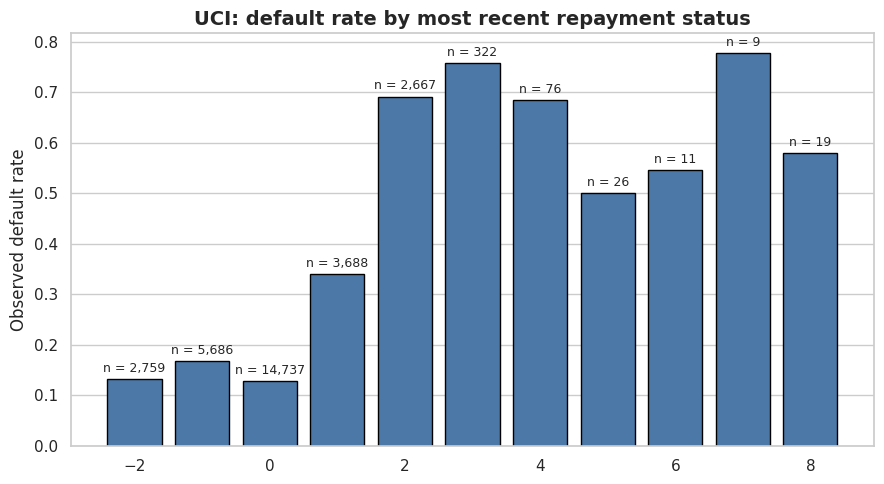

In [ ]:
uci_pay_rates = uci_raw.groupby("PAY_0")["default"].agg(["mean", "count"]).reset_index()
uci_pay_rates.to_csv(
    OUTPUT_DIRS["UCI_Credit_Card"]["results"] / "default_rate_by_PAY_0.csv", index=False
)
display(uci_pay_rates)

counts = uci_pay_rates["count"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    uci_pay_rates["PAY_0"],
    uci_pay_rates["mean"],
    color="#4C78A8",
    edgecolor="black",
    linewidth=1,
)

count_labels = [
    f"n = {int(count):,}"
    for count in counts
]

ax.bar_label(bars, labels=count_labels, padding=3, fontsize=9)

ax.set_ylabel("Observed default rate")
ax.set_title("UCI: default rate by most recent repayment status", fontsize=14, fontweight="bold")
ax.xaxis.grid(False)
save_and_show(OUTPUT_DIRS["UCI_Credit_Card"]["figures"] / "default_rate_by_PAY_0.png")

## Exploratory Data Analysis: German Credit

### German descriptive and statstics and data-quality table

In [ ]:
german_raw.describe(include="all").T.to_csv(
    OUTPUT_DIRS["German_Credit"]["results"] / "descriptive_statistics.csv"
)
pd.DataFrame({
    "missing": german_raw.isna().sum(),
    "duplicate": german_raw.nunique(),
}).to_csv(OUTPUT_DIRS["German_Credit"]["results"] / "data_quality_by_feature.csv")
display(german_raw.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
checking_status,1000,4,none,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_months,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
credit_history,1000,5,existing_paid_duly,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,radio_tv,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
savings_status,1000,5,lt_100,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment,1000,5,1_to_4_years,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment_rate,1000.0,NaN,NaN,NaN,2.973,1.118715,1.0,2.0,3.0,4.0,4.0
personal_status_sex,1000,4,male_single,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_debtors,1000,3,none,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### German target distributions

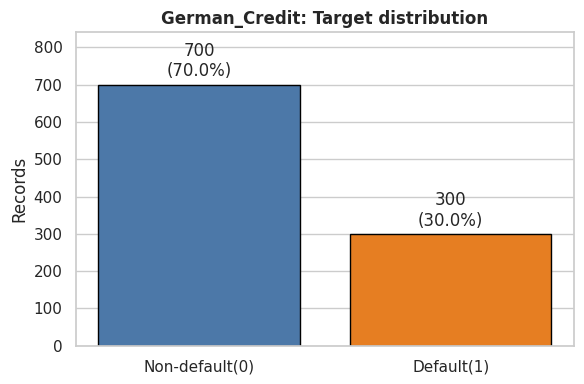

In [ ]:
target_distribution_plot("German_Credit", german_raw)

### German numeric distributions

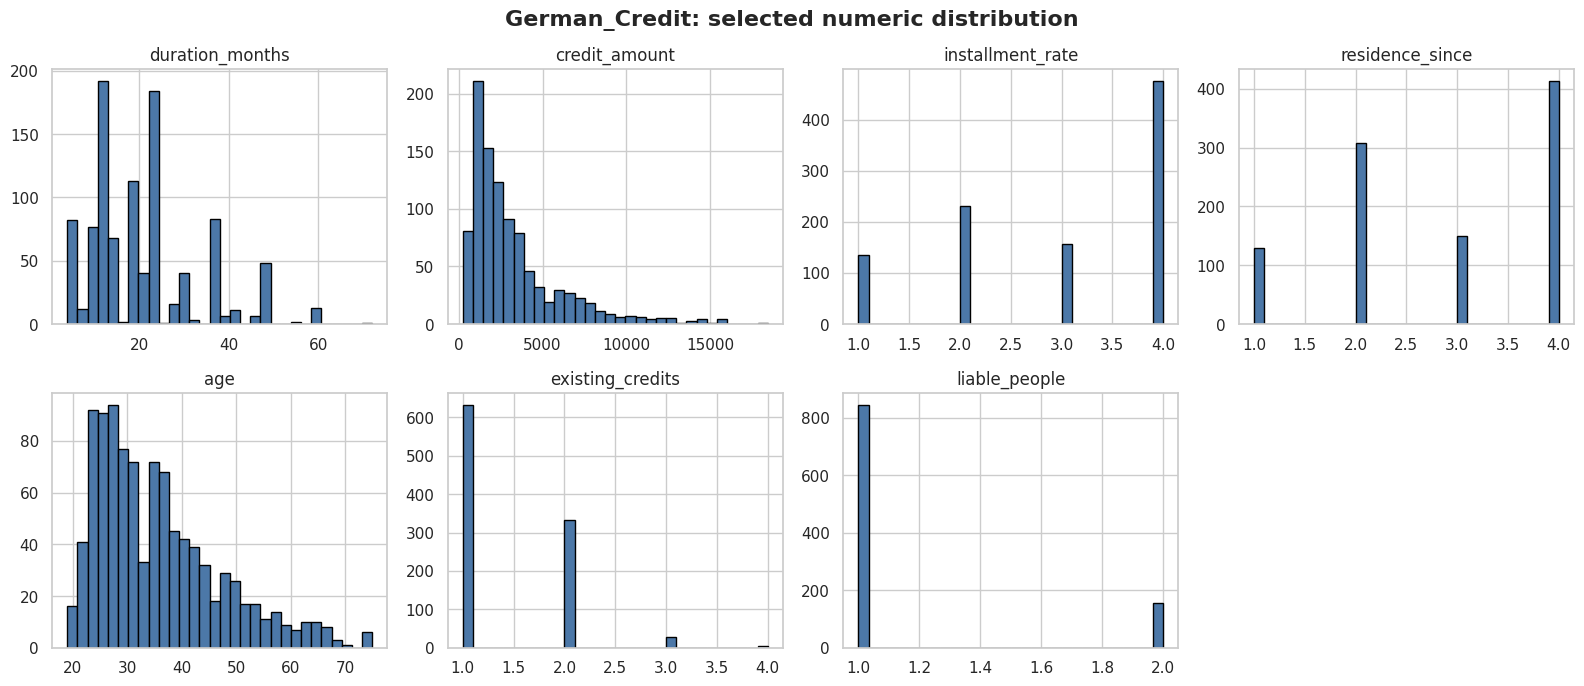

In [ ]:
numeric_distribution_plot("German_Credit", german_raw)

### German Spearman correlation

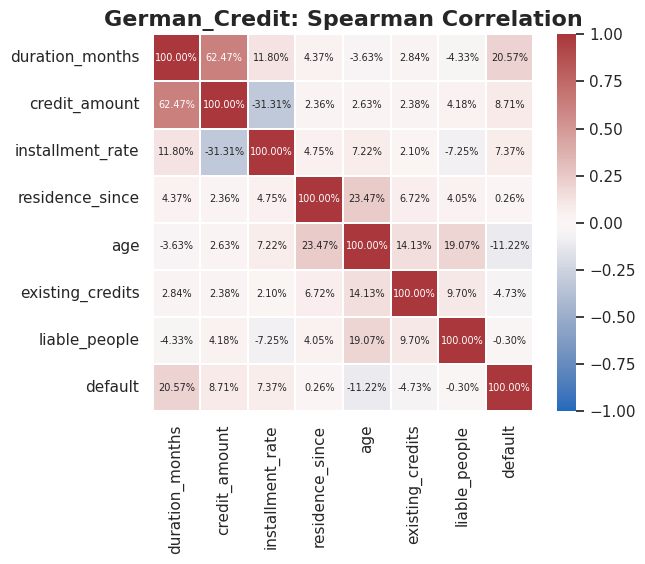

In [ ]:
correlation_plot("German_Credit", german_raw)

### German Categorical default rates

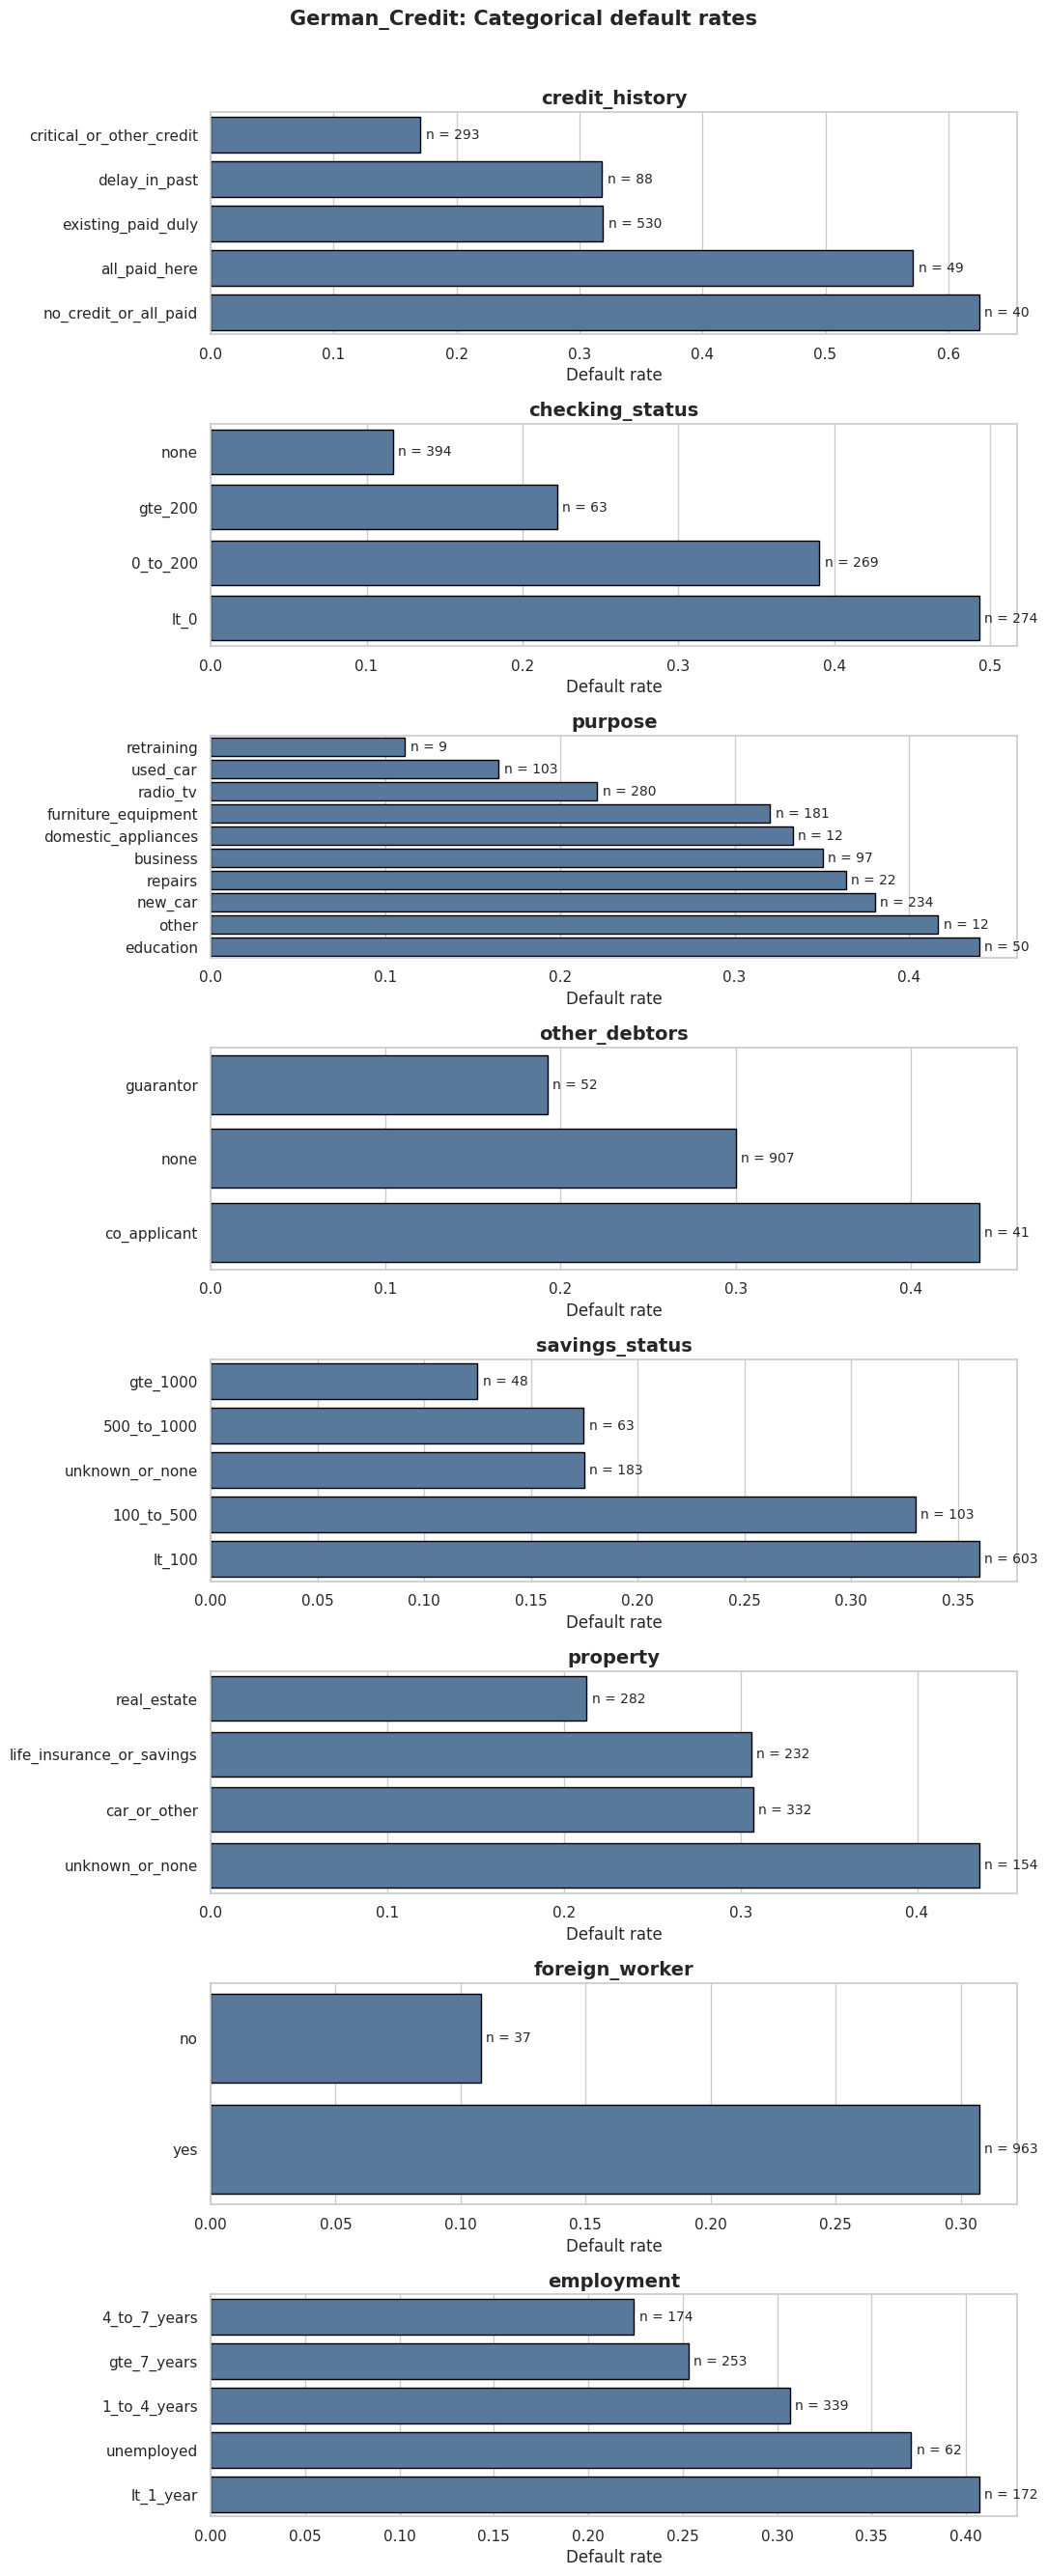

In [ ]:
categorical_default_rate_plot("German_Credit", german_raw)

## Dataset-specific feature engineering

### UCI feature-engineering function

In [ ]:
def safe_ratio(numerator, denominator, lower=-10, upper=10):
    denominator = np.where(np.abs(denominator) < 1e-9, np.nan, denominator)
    ratio = np.asarray(numerator, dtype=float) / denominator
    return np.clip(ratio, lower, upper)


def add_uci_features(df):
    result = df.copy()
    pay_status = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
    bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
    payment_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

    result["DELAY_MONTH_COUNT"] = (result[pay_status] > 0).sum(axis=1)
    result["SEVERE_DELAY_MONTH_COUNT"] = (result[pay_status] >= 2).sum(axis=1)
    result["MAX_REPAYMENT_STATUS"] = result[pay_status].max(axis=1)
    result["MEAN_REPAYMENT_STATUS"] = result[pay_status].mean(axis=1)
    result["REPAYMENT_STATUS_TREND"] = result["PAY_0"] - result["PAY_6"]

    result["TOTAL_BILL_AMT"] = result[bill_cols].sum(axis=1)
    result["MEAN_BILL_AMT"] = result[bill_cols].mean(axis=1)
    result["BILL_AMT_VOLATILITY"] = result[bill_cols].std(axis=1)
    result["BILL_AMT_TREND"] = result["BILL_AMT1"] - result["BILL_AMT6"]

    result["TOTAL_PAY_AMT"] = result[payment_cols].sum(axis=1)
    result["MEAN_PAY_AMT"] = result[payment_cols].mean(axis=1)
    result["PAY_AMT_VOLATILITY"] = result[payment_cols].std(axis=1)
    result["PAY_AMT_TREND"] = result["PAY_AMT1"] - result["PAY_AMT6"]

    result["CURRENT_UTILIZATION"] = safe_ratio(result["BILL_AMT1"], result["LIMIT_BAL"])
    result["MEAN_UTILIZATION"] = safe_ratio(result["MEAN_BILL_AMT"], result["LIMIT_BAL"])
    result["PAYMENT_TO_BILL_RATIO"] = safe_ratio(
        result["TOTAL_PAY_AMT"], np.abs(result["TOTAL_BILL_AMT"]) + 1
    )
    result["CREDIT_HEADROOM"] = result["LIMIT_BAL"] - result["BILL_AMT1"]
    return result

### German Credit feature engineering

In [ ]:
def add_german_features(df):
    result = df.copy()
    result["credit_per_month"] = safe_ratio(result["credit_amount"], result["duration_months"], 0, 100_000)
    result["duration_years"] = result["duration_months"] / 12.0
    result["credit_amount_per_age"] = safe_ratio(result["credit_amount"], result["age"], 0, 100_000)
    result["installment_burden_proxy"] = safe_ratio(
        result["credit_amount"] * result["installment_rate"], result["duration_months"], 0, 500_000
    )
    result["age_band"] = pd.cut(
        result["age"], bins=[0, 25, 35, 50, 65, np.inf],
        labels=["under_26", "26_to_35", "36_to_50", "51_to_65", "over_65"],
    ).astype(str)
    result["duration_band"] = pd.cut(
        result["duration_months"], bins=[0, 12, 24, 36, 48, np.inf],
        labels=["up_to_12", "13_to_24", "25_to_36", "37_to_48", "over_48"],
    ).astype(str)
    result["credit_amount_band"] = pd.cut(
        result["credit_amount"], bins=[0, 1_500, 3_000, 6_000, 10_000, np.inf],
        labels=["up_to_1500", "1501_to_3000", "3001_to_6000", "6001_to_10000", "over_10000"],
    ).astype(str)
    return result

### Apply feature engineering and save model-ready data

In [ ]:
uci = add_uci_features(uci_raw)
german = add_german_features(german_raw)

MODEL_DATASETS = {
    "UCI_Credit_Card": uci,
    "German_Credit": german,
}

for dataset_name, model_df in MODEL_DATASETS.items():
    model_df.to_csv(
        OUTPUT_DIRS[dataset_name]["processed"] / "model_ready.csv",
        index=True, index_label="source_row_index"
    )

feature_engineering_summary = pd.DataFrame({
    "dataset": ["UCI_Credit_Card", "German_Credit"],
    "raw_predictors": [uci_raw.shape[1] - 1, german_raw.shape[1] - 1],
    "engineered_predictors": [uci.shape[1] - 1, german.shape[1] - 1],
})
display(feature_engineering_summary)
feature_engineering_summary.to_csv(COMPARISON_DIR / "feature_engineering_summary.csv", index=False)

,dataset,raw_predictors,engineered_predictors
0,UCI_Credit_Card,23,40
1,German_Credit,20,27


## Data Preprocessing

In [ ]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_preprocessor(X):
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])
    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ], remainder="drop", sparse_threshold=0.3)
    return preprocessor, numeric_features, categorical_features


def create_dataset_split(dataset_name, df):
    X = df.drop(columns="default")
    y = df["default"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )
    preprocessor, numeric_features, categorical_features = make_preprocessor(X_train)
    return {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "preprocessor": preprocessor,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
    }

### UCI split

In [ ]:
uci_split = create_dataset_split("UCI_Credit_Card", uci)
print(uci_split["X_train"].shape, uci_split["X_test"].shape)

(24000, 40) (6000, 40)


### German split

In [ ]:
german_split = create_dataset_split("German_Credit", german)
print(german_split["X_train"].shape, german_split["X_test"].shape)

(800, 27) (200, 27)


In [ ]:
splits = {
    "UCI_Credit_Card": uci_split,
    "German_Credit": german_split,
}
split_summary = pd.DataFrame([
    {
        "dataset": name,
        "train_rows": len(split["X_train"]),
        "test_rows": len(split["X_test"]),
        "train_default_rate": split["y_train"].mean(),
        "test_default_rate": split["y_test"].mean(),
        "numeric_features": len(split["numeric_features"]),
        "categorical_features": len(split["categorical_features"]),
    }
    for name, split in splits.items()
])
display(split_summary.style.format({
    "train_default_rate": "{:.2%}", "test_default_rate": "{:.2%}"
}))
split_summary.to_csv(COMPARISON_DIR / "train_test_split_summary.csv", index=False)

,dataset,train_rows,test_rows,train_default_rate,test_default_rate,numeric_features,categorical_features
0,UCI_Credit_Card,24000,6000,22.12%,22.12%,37,3
1,German_Credit,800,200,30.00%,30.00%,11,16


## Model Development

In [ ]:
def build_model_specs():
    return {
        "Dummy": {
            "estimator": DummyClassifier(strategy="prior", random_state=RANDOM_STATE),
            "params": {},
        },
        "Logistic_Regression": {
            "estimator": LogisticRegression(max_iter=2_000, solver="liblinear", random_state=RANDOM_STATE),
            "params": {
                "model__C": loguniform(1e-3, 1e2),
                "model__penalty": ["l1", "l2"],
                "model__class_weight": [None, "balanced"],
            },
        },
        "SVM": {
            "estimator": SVC(probability=True, cache_size=2_000, random_state=RANDOM_STATE),
            "params": {
                "model__C": loguniform(1e-2, 1e2),
                "model__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1],
                "model__kernel": ["rbf"],
                "model__class_weight": [None, "balanced"],
            },
        },
        "KNN": {
            "estimator": KNeighborsClassifier(),
            "params": {
                "model__n_neighbors": [5, 9, 15, 21, 31, 51],
                "model__weights": ["uniform", "distance"],
                "model__p": [1, 2],
            },
        },
        "MLP": {
            "estimator": MLPClassifier(
                max_iter=400, early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=20, random_state=RANDOM_STATE,
            ),
            "params": {
                "model__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
                "model__activation": ["relu", "tanh"],
                "model__alpha": loguniform(1e-5, 1e-1),
                "model__learning_rate_init": loguniform(1e-4, 1e-2),
            },
        },
        "Random_Forest": {
            "estimator": RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
            "params": {
                "model__n_estimators": [250, 400, 600],
                "model__max_depth": [None, 8, 15, 25],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 5],
                "model__max_features": ["sqrt", "log2", 0.5],
                "model__class_weight": [None, "balanced", "balanced_subsample"],
            },
        },
        "XGBoost": {
            "estimator": xgb.XGBClassifier(
                objective="binary:logistic", eval_metric="logloss", tree_method="hist",
                n_jobs=-1, random_state=RANDOM_STATE,
            ),
            "params": {
                "model__n_estimators": [200, 350, 500, 700],
                "model__max_depth": [3, 4, 5, 7],
                "model__learning_rate": [0.02, 0.05, 0.1, 0.2],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
                "model__min_child_weight": [1, 3, 5, 10],
                "model__reg_lambda": [0.5, 1.0, 5.0, 10.0],
            },
        },
        "LightGBM": {
            "estimator": lgb.LGBMClassifier(
                objective="binary", n_jobs=-1, verbosity=-1,
                random_state=RANDOM_STATE,
            ),
            "params": {
                "model__n_estimators": [200, 350, 500, 700],
                "model__num_leaves": [15, 31, 63, 127],
                "model__max_depth": [-1, 5, 10, 20],
                "model__learning_rate": [0.02, 0.05, 0.1, 0.2],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
                "model__min_child_samples": [10, 20, 40, 80],
                "model__reg_lambda": [0.0, 1.0, 5.0, 10.0],
                "model__class_weight": [None, "balanced"],
            },
        },
    }

In [ ]:
def positive_class_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    scores = estimator.decision_function(X)
    return 1 / (1 + np.exp(-scores))


def calculate_metrics(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "brier_score": brier_score_loss(y_true, y_score),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


SCORING = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "balanced_accuracy": "balanced_accuracy",
}
CV = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
def train_dataset_models(dataset_name, split):
    X_train, X_test = split["X_train"], split["X_test"]
    y_train, y_test = split["y_train"], split["y_test"]
    model_specs = build_model_specs()

    fitted_models = {}
    predictions = {}
    rows = []

    for model_name, spec in model_specs.items():
        print(f"\n[{dataset_name}] Training {model_name}...")
        started = time.time()
        pipeline = Pipeline([
            ("preprocess", clone(split["preprocessor"])),
            ("model", clone(spec["estimator"])),
        ])

        if spec["params"]:
            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=spec["params"],
                n_iter=SEARCH_ITERATIONS,
                scoring=SCORING,
                refit=PRIMARY_METRIC,
                cv=CV,
                n_jobs=-1,
                verbose=1,
                random_state=RANDOM_STATE,
                return_train_score=False,
                error_score="raise",
            )
        else:
            search = GridSearchCV(
                estimator=pipeline,
                param_grid={},
                scoring=SCORING,
                refit=PRIMARY_METRIC,
                cv=CV,
                n_jobs=-1,
                return_train_score=False,
                error_score="raise",
            )

        search.fit(X_train, y_train)
        best = search.best_estimator_
        y_score = positive_class_scores(best, X_test)
        y_pred = (y_score >= 0.50).astype(int)
        test_metrics = calculate_metrics(y_test, y_pred, y_score)
        if dataset_name == "German_Credit":
            test_metrics["documented_total_cost"] = test_metrics["fp"] + 5 * test_metrics["fn"]
            test_metrics["documented_cost_per_applicant"] = (
                test_metrics["documented_total_cost"] / len(y_test)
            )
        else:
            test_metrics["documented_total_cost"] = np.nan
            test_metrics["documented_cost_per_applicant"] = np.nan
        best_idx = search.best_index_

        row = {
            "dataset": dataset_name,
            "model": model_name,
            "cv_roc_auc_mean": search.cv_results_["mean_test_roc_auc"][best_idx],
            "cv_roc_auc_std": search.cv_results_["std_test_roc_auc"][best_idx],
            "cv_pr_auc_mean": search.cv_results_["mean_test_pr_auc"][best_idx],
            "cv_f1_mean": search.cv_results_["mean_test_f1"][best_idx],
            "cv_recall_mean": search.cv_results_["mean_test_recall"][best_idx],
            "cv_precision_mean": search.cv_results_["mean_test_precision"][best_idx],
            "cv_balanced_accuracy_mean": search.cv_results_["mean_test_balanced_accuracy"][best_idx],
            **{f"test_{key}": value for key, value in test_metrics.items()},
            "best_parameters": json.dumps(search.best_params_, default=str, sort_keys=True),
            "runtime_seconds": time.time() - started,
        }
        rows.append(row)
        fitted_models[model_name] = best
        predictions[model_name] = pd.DataFrame({
            "row_index": X_test.index,
            "y_true": y_test.to_numpy(),
            "y_pred_0_5": y_pred,
            "default_probability": y_score,
        })

        cv_table = pd.DataFrame(search.cv_results_).sort_values("rank_test_roc_auc")
        cv_table.to_csv(OUTPUT_DIRS[dataset_name]["results"] / f"{model_name}_cv_results.csv", index=False)
        joblib.dump(best, OUTPUT_DIRS[dataset_name]["models"] / f"{model_name}_pipeline.joblib")
        predictions[model_name].to_csv(
            OUTPUT_DIRS[dataset_name]["results"] / f"{model_name}_test_predictions.csv", index=False
        )
        print(
            f"Best CV ROC-AUC={row['cv_roc_auc_mean']:.4f}; "
            f"Test ROC-AUC={row['test_roc_auc']:.4f}; Test PR-AUC={row['test_pr_auc']:.4f}"
        )

    return pd.DataFrame(rows), fitted_models, predictions

### Train and tune the UCI models

In [ ]:
uci_metrics, uci_fitted_models, uci_test_predictions = train_dataset_models(
    "UCI_Credit_Card", splits["UCI_Credit_Card"]
)


[UCI_Credit_Card] Training Dummy...
Best CV ROC-AUC=0.5000; Test ROC-AUC=0.5000; Test PR-AUC=0.2212

[UCI_Credit_Card] Training Logistic_Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV ROC-AUC=0.7675; Test ROC-AUC=0.7563; Test PR-AUC=0.5191

[UCI_Credit_Card] Training SVM...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV ROC-AUC=0.7643; Test ROC-AUC=0.7541; Test PR-AUC=0.4801

[UCI_Credit_Card] Training KNN...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV ROC-AUC=0.7636; Test ROC-AUC=0.7607; Test PR-AUC=0.5209

[UCI_Credit_Card] Training MLP...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV ROC-AUC=0.7787; Test ROC-AUC=0.7745; Test PR-AUC=0.5556

[UCI_Credit_Card] Training Random_Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV ROC-AUC=0.7867; Test ROC-AUC=0.7800; Test PR-AUC=0.5613

[UCI_Credit_Card] Training XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV ROC-AUC=0.7888; Test ROC-AUC=0.7835; Test PR-AUC=0.5621

[UCI_Credit_Card] Training LightGBM...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best CV ROC-AUC=0.7877; Test ROC-AUC=0.7840; Test PR-AUC=0.5640


### German Train and Tune

In [ ]:
german_metrics, german_fitted_models, german_test_predictions = train_dataset_models(
    "German_Credit", splits["German_Credit"]
)


[German_Credit] Training Dummy...
Best CV ROC-AUC=0.5000; Test ROC-AUC=0.5000; Test PR-AUC=0.3000

[German_Credit] Training Logistic_Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV ROC-AUC=0.7593; Test ROC-AUC=0.8086; Test PR-AUC=0.6458

[German_Credit] Training SVM...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV ROC-AUC=0.7882; Test ROC-AUC=0.7800; Test PR-AUC=0.6170

[German_Credit] Training KNN...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV ROC-AUC=0.7759; Test ROC-AUC=0.7417; Test PR-AUC=0.6091

[German_Credit] Training MLP...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV ROC-AUC=0.7858; Test ROC-AUC=0.8120; Test PR-AUC=0.7045

[German_Credit] Training Random_Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV ROC-AUC=0.7973; Test ROC-AUC=0.7876; Test PR-AUC=0.6530

[German_Credit] Training XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 2

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
metrics = pd.concat([uci_metrics, german_metrics], ignore_index=True)
fitted_models = {
    "UCI_Credit_Card": uci_fitted_models,
    "German_Credit": german_fitted_models,
}
test_predictions = {
    "UCI_Credit_Card": uci_test_predictions,
    "German_Credit": german_test_predictions,
}
metrics.to_csv(COMPARISON_DIR / "all_model_metrics.csv", index=False)
display(metrics.sort_values(["dataset", "cv_roc_auc_mean"], ascending=[True, False]))

,dataset,model,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_f1_mean,cv_recall_mean,cv_precision_mean,cv_balanced_accuracy_mean,test_accuracy,...,test_mcc,test_brier_score,test_tn,test_fp,test_fn,test_tp,test_documented_total_cost,test_documented_cost_per_applicant,best_parameters,runtime_seconds
13,German_Credit,Random_Forest,0.797335,0.018971,0.616518,0.591327,0.600000,0.583237,0.708037,0.725000,...,0.380788,0.179613,107,33,22,38,143.0,0.715,"{""model__class_weight"": ""balanced_subsample"", ...",27.613398
14,German_Credit,XGBoost,0.789080,0.025484,0.604003,0.498716,0.408333,0.648062,0.655051,0.790000,...,0.466108,0.158921,128,12,30,30,162.0,0.810,"{""model__colsample_bytree"": 0.7, ""model__learn...",7.042450
15,German_Credit,LightGBM,0.788464,0.021565,0.589971,0.484554,0.404167,0.614759,0.645823,0.785000,...,0.457253,0.156814,126,14,29,31,159.0,0.795,"{""model__class_weight"": null, ""model__colsampl...",16.649446
10,German_Credit,SVM,0.788228,0.014364,0.605984,0.587420,0.645833,0.539018,0.704172,0.760000,...,0.394089,0.165355,123,17,31,29,172.0,0.860,"{""model__C"": 1.256104370001356, ""model__class_...",4.903941
12,German_Credit,MLP,0.785803,0.026246,0.580475,0.501270,0.416667,0.642725,0.655677,0.815000,...,0.543215,0.148527,126,14,23,37,129.0,0.645,"{""model__activation"": ""relu"", ""model__alpha"": ...",5.573541
11,German_Credit,KNN,0.775853,0.015535,0.577506,0.270635,0.166667,0.722188,0.569044,0.755000,...,0.348026,0.172903,132,8,41,19,213.0,1.065,"{""model__n_neighbors"": 21, ""model__p"": 1, ""mod...",1.362799
9,German_Credit,Logistic_Regression,0.759305,0.029371,0.562501,0.567865,0.654167,0.504869,0.687802,0.715000,...,0.439697,0.182555,95,45,12,48,105.0,0.525,"{""model__C"": 1.0129197956845732, ""model__class...",2.941100
8,German_Credit,Dummy,0.500000,0.000000,0.300001,0.000000,0.000000,0.000000,0.500000,0.700000,...,0.000000,0.210000,140,0,60,0,300.0,1.500,{},0.553409
6,UCI_Credit_Card,XGBoost,0.788830,0.004476,0.560813,0.480706,0.372572,0.677926,0.661113,0.820833,...,0.405661,0.134180,4430,243,832,495,NaN,NaN,"{""model__colsample_bytree"": 1.0, ""model__learn...",44.400604
7,UCI_Credit_Card,LightGBM,0.787700,0.004413,0.562012,0.477297,0.368429,0.678013,0.659336,0.820500,...,0.402768,0.133829,4437,236,841,486,NaN,NaN,"{""model__class_weight"": null, ""model__colsampl...",229.500325


All trained models outperformed the Dummy baseline (ROC–AUC = 0.500), confirming that the predictors contain meaningful information for credit-risk discrimination. For German Credit, Random Forest achieved the highest mean ROC–AUC (0.797 ± 0.019), followed closely by XGBoost, LightGBM, and SVM (approximately 0.788–0.789). SVM showed the greatest consistency among the leading models, with the lowest standard deviation. For UCI Credit Card, XGBoost (0.789 ± 0.004) and LightGBM (0.788 ± 0.004) produced nearly identical and highly stable results. Overall, ensemble models performed strongly, although their small performance differences should be confirmed using holdout-test metrics before selecting the final model.

In [ ]:
def plot_cv_model_comparison(dataset_name, metrics_df):
    out = OUTPUT_DIRS[dataset_name]
    plot_df = metrics_df.sort_values(
        "cv_roc_auc_mean",
        ascending=False
    )

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.bar(
        x=plot_df["model"],
        height=plot_df["cv_roc_auc_mean"],
        yerr=plot_df["cv_roc_auc_std"],
        color="#4C78A8",
        edgecolor="black",
        linewidth=1,
        capsize=4
    )

    score_labels = [
        f"{score:.3f}"
        for score in plot_df["cv_roc_auc_mean"]
    ]

    ax.bar_label(
        bars,
        labels=score_labels,
        padding=5,
        fontsize=10
    )

    # Chance-level ROC-AUC
    ax.axhline(
        y=0.5,
        color="red",
        linestyle="--",
        linewidth=1,
        label="Chance level"
    )

    ax.set_ylim(0, 1)
    ax.set_xlabel("Model")
    ax.set_ylabel("Mean Cross-Validation ROC-AUC")

    ax.set_title(
        f"{dataset_name}: Model Training Comparison",
        fontsize=14,
        fontweight="bold"
    )

    ax.tick_params(
        axis="x",
        labelrotation=30
    )

    ax.legend()
    ax.grid(False)

    save_and_show(
        out["figures"] / "cv_model_comparison_vertical.png"
    )

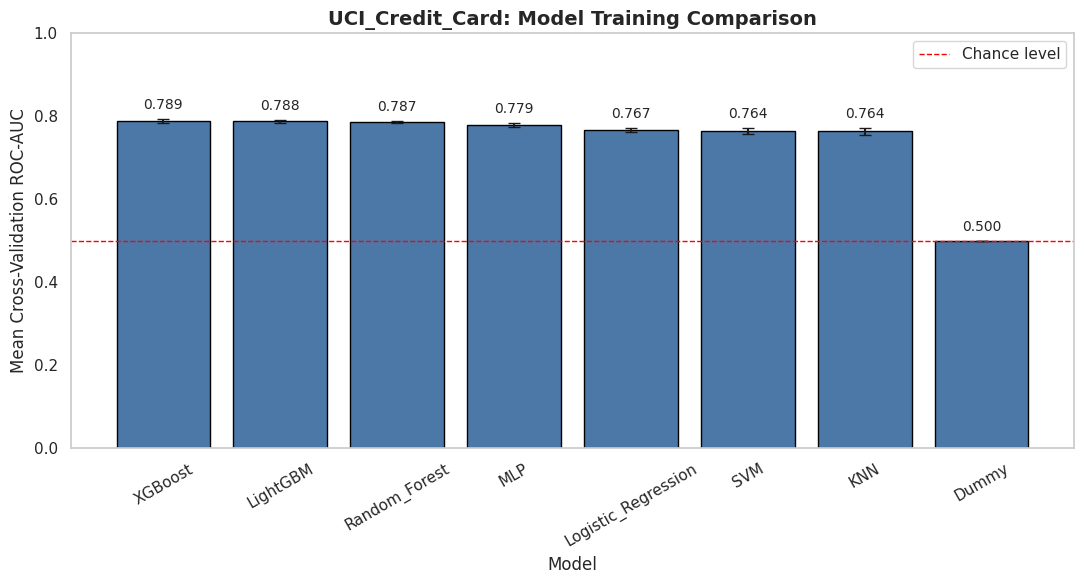

In [ ]:
plot_cv_model_comparison(
    "UCI_Credit_Card",
    uci_metrics
)

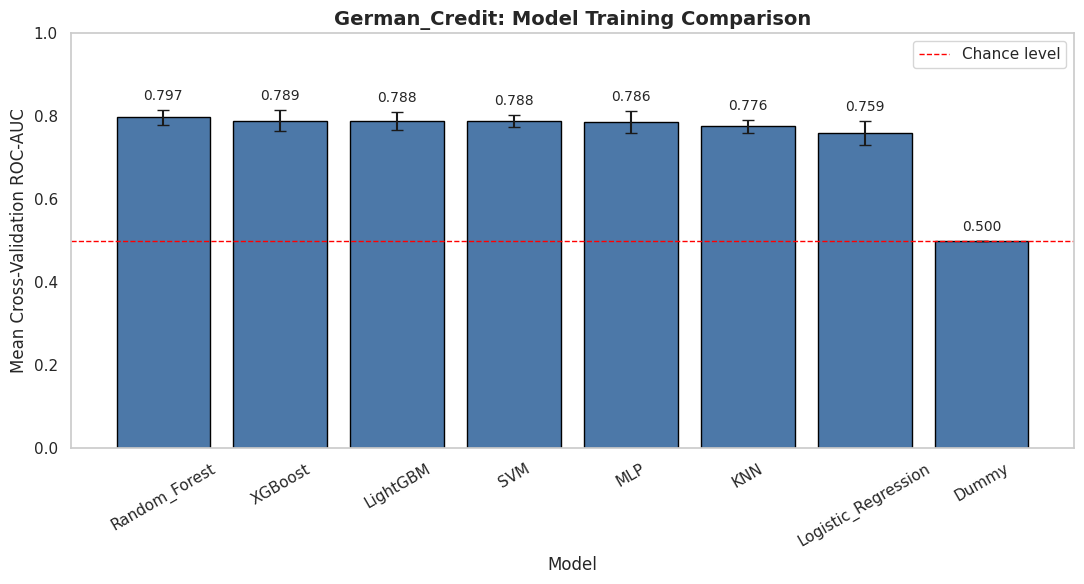

In [ ]:
plot_cv_model_comparison(
    "German_Credit",
    german_metrics
)

### Champion Model Selection

In [ ]:
champions = {}
champion_rows = []

for dataset_name in metrics["dataset"].unique():
    eligible = metrics[(metrics["dataset"] == dataset_name) & (metrics["model"] != "Dummy")]
    champion_row = eligible.sort_values("cv_roc_auc_mean", ascending=False).iloc[0]
    champion_name = champion_row["model"]
    champions[dataset_name] = champion_name
    champion_rows.append(champion_row)
    print(
        f"{dataset_name} champion: {champion_name} "
        f"(CV ROC-AUC={champion_row['cv_roc_auc_mean']:.4f}, "
        f"Test ROC-AUC={champion_row['test_roc_auc']:.4f})"
    )

champion_summary = pd.DataFrame(champion_rows).reset_index(drop=True)
champion_summary.to_csv(COMPARISON_DIR / "champion_model_summary.csv", index=False)
display(champion_summary)


UCI_Credit_Card champion: XGBoost (CV ROC-AUC=0.7888, Test ROC-AUC=0.7835)
German_Credit champion: Random_Forest (CV ROC-AUC=0.7973, Test ROC-AUC=0.7876)


,dataset,model,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_f1_mean,cv_recall_mean,cv_precision_mean,cv_balanced_accuracy_mean,test_accuracy,...,test_mcc,test_brier_score,test_tn,test_fp,test_fn,test_tp,test_documented_total_cost,test_documented_cost_per_applicant,best_parameters,runtime_seconds
0,UCI_Credit_Card,XGBoost,0.788830,0.004476,0.560813,0.480706,0.372572,0.677926,0.661113,0.820833,...,0.405661,0.134180,4430,243,832,495,NaN,NaN,"{""model__colsample_bytree"": 1.0, ""model__learn...",44.400604
1,German_Credit,Random_Forest,0.797335,0.018971,0.616518,0.591327,0.600000,0.583237,0.708037,0.725000,...,0.380788,0.179613,107,33,22,38,143.0,0.715,"{""model__class_weight"": ""balanced_subsample"", ...",27.613398


XGBoost was selected as the champion model for UCI Credit Card, achieving a CV ROC–AUC of 0.7888 and a test ROC–AUC of 0.7835. Random Forest was selected for German Credit, with corresponding scores of 0.7973 and 0.7876. The small CV-to-test reductions of 0.0053 and 0.0097, respectively, indicate limited overfitting and satisfactory generalisation to unseen data. Therefore, these models were retained for subsequent evaluation and explainability analysis.

### Held-out Evaluation Plots

In [ ]:
def plot_dataset_evaluation(dataset_name):
    subset = metrics[metrics["dataset"] == dataset_name].sort_values("cv_roc_auc_mean")
    split = splits[dataset_name]
    y_test = split["y_test"]

    # CV vs test ROC-AUC comparison.
    long_auc = subset.melt(
        id_vars="model",
        value_vars=["cv_roc_auc_mean", "test_roc_auc"],
        var_name="evaluation", value_name="roc_auc",
    )
    plt.figure(figsize=(10, 5))
    sns.barplot(data=long_auc, x="roc_auc", y="model", hue="evaluation")
    plt.axvline(0.5, color="black", linestyle="--", linewidth=1)
    plt.xlim(0.45, 1.0)
    plt.title(f"{dataset_name}: cross-validation vs test ROC-AUC")
    save_and_show(OUTPUT_DIRS[dataset_name]["figures"] / "cv_vs_test_roc_auc.png")

    # ROC curves.
    plt.figure(figsize=(8, 6))
    for model_name, pred in test_predictions[dataset_name].items():
        fpr, tpr, _ = roc_curve(pred["y_true"], pred["default_probability"])
        auc = roc_auc_score(pred["y_true"], pred["default_probability"])
        plt.plot(fpr, tpr, label=f"{model_name} ({auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False-positive rate")
    plt.ylabel("True-positive rate")
    plt.title(f"{dataset_name}: held-out ROC curves")
    plt.legend(loc="lower right", fontsize=8)
    save_and_show(OUTPUT_DIRS[dataset_name]["figures"] / "test_roc_curves.png")

    # Precision-recall curves.
    plt.figure(figsize=(8, 6))
    for model_name, pred in test_predictions[dataset_name].items():
        precision, recall, _ = precision_recall_curve(pred["y_true"], pred["default_probability"])
        ap = average_precision_score(pred["y_true"], pred["default_probability"])
        plt.plot(recall, precision, label=f"{model_name} ({ap:.3f})")
    plt.axhline(y_test.mean(), color="black", linestyle="--", label="Prevalence baseline")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{dataset_name}: held-out precision-recall curves")
    plt.legend(loc="best", fontsize=8)
    save_and_show(OUTPUT_DIRS[dataset_name]["figures"] / "test_pr_curves.png")

    champion_name = champions[dataset_name]
    champion = fitted_models[dataset_name][champion_name]
    pred = test_predictions[dataset_name][champion_name]

    cm = confusion_matrix(pred["y_true"], pred["y_pred_0_5"], labels=[0, 1])
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Non-default", "Default"], yticklabels=["Non-default", "Default"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{dataset_name}: {champion_name} confusion matrix")
    save_and_show(OUTPUT_DIRS[dataset_name]["figures"] / f"{champion_name}_confusion_matrix.png")

    fig, ax = plt.subplots(figsize=(7, 6))
    CalibrationDisplay.from_estimator(
        champion, split["X_test"], split["y_test"], n_bins=10,
        strategy="quantile", name=champion_name, ax=ax,
    )
    ax.set_title(f"{dataset_name}: champion calibration")
    save_and_show(OUTPUT_DIRS[dataset_name]["figures"] / f"{champion_name}_calibration.png")

    report = classification_report(
        pred["y_true"], pred["y_pred_0_5"],
        target_names=["non_default", "default"], output_dict=True, zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(
        OUTPUT_DIRS[dataset_name]["results"] / f"{champion_name}_classification_report.csv"
    )

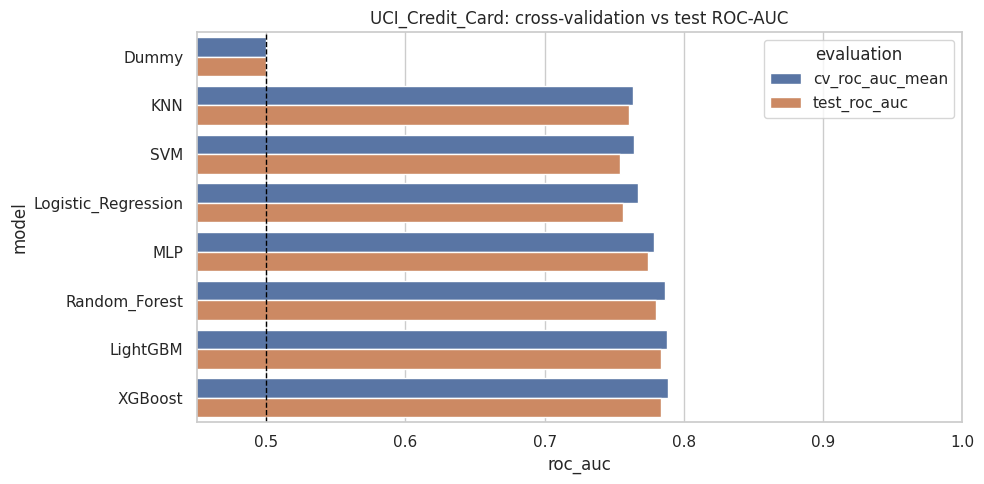

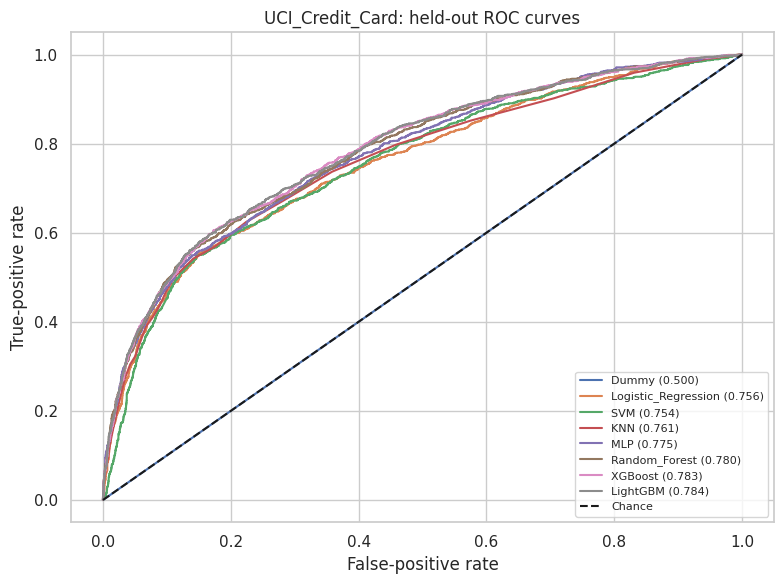

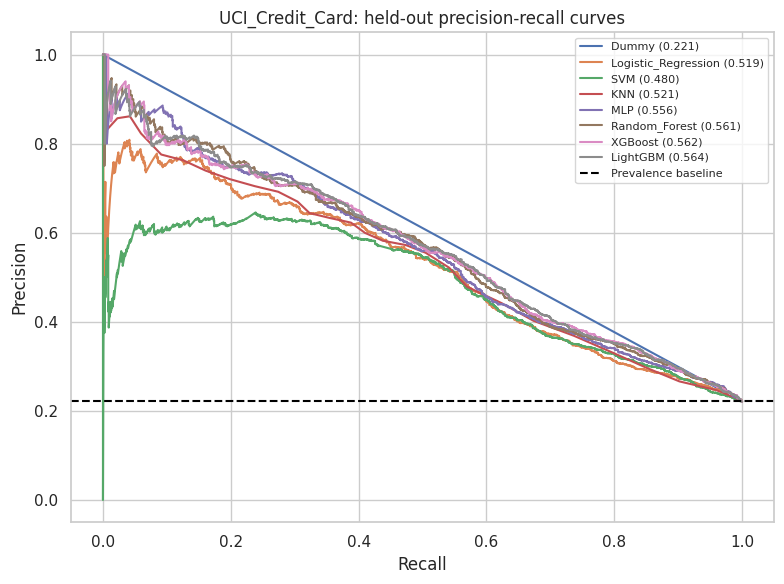

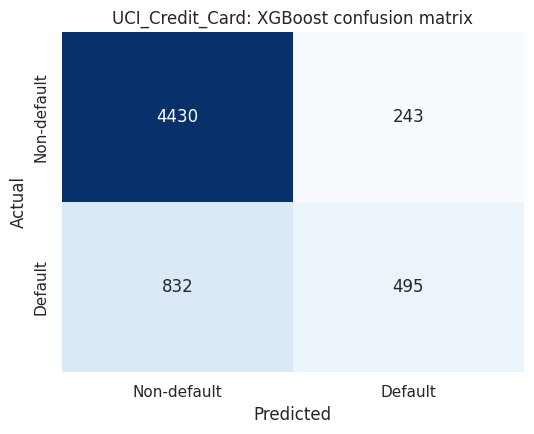

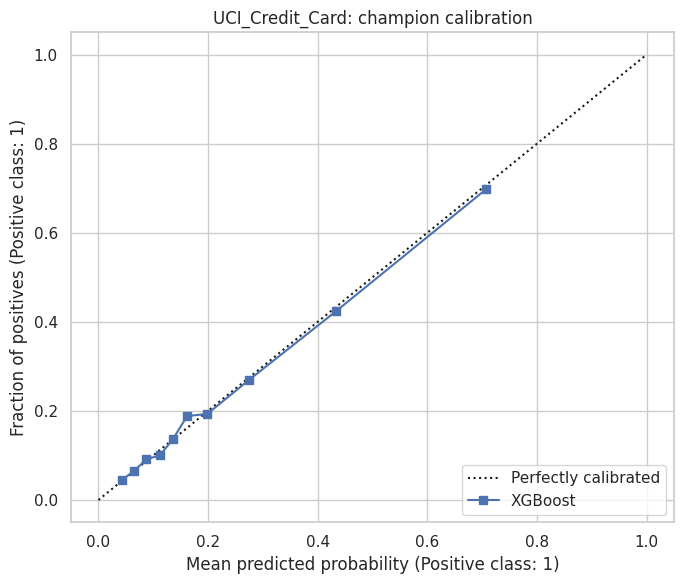

In [ ]:
plot_dataset_evaluation("UCI_Credit_Card")

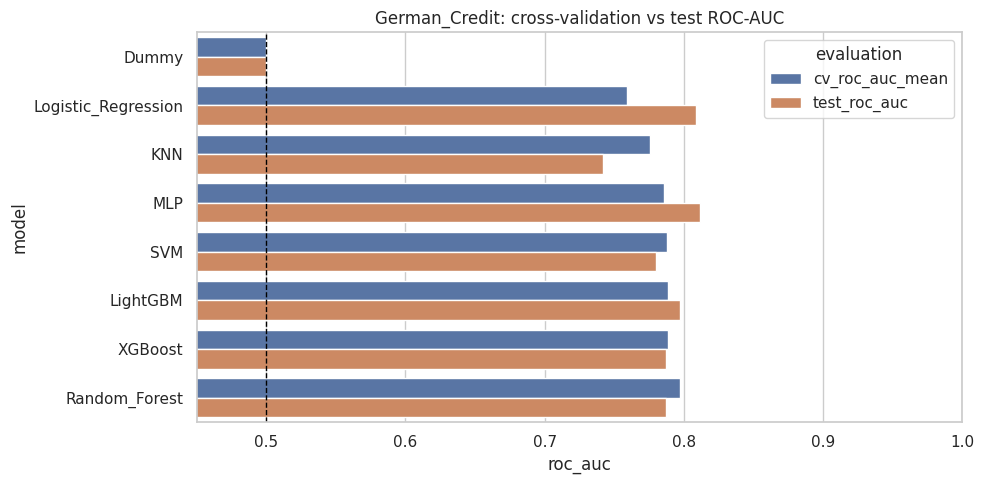

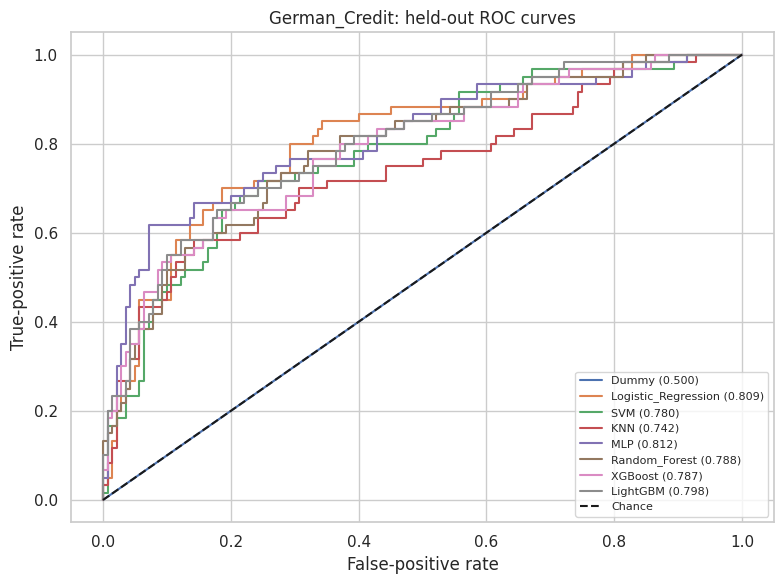

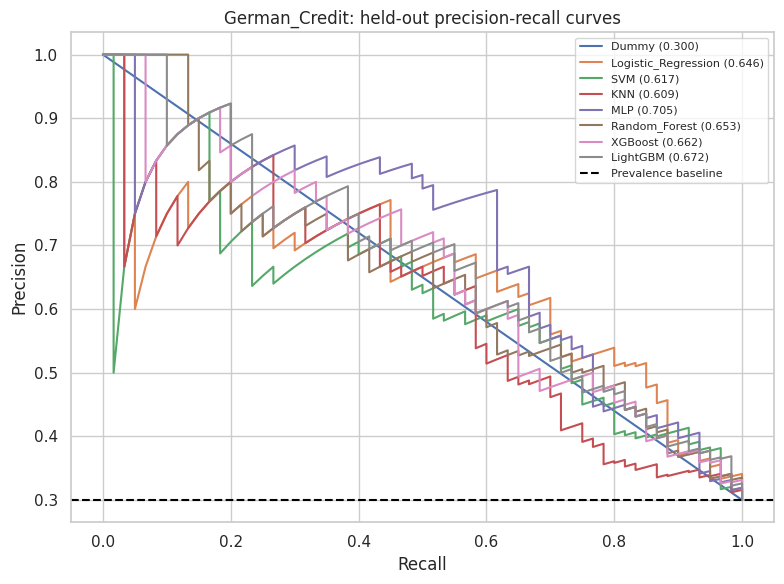

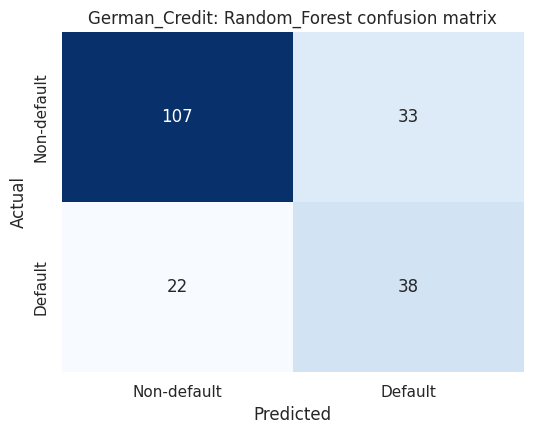

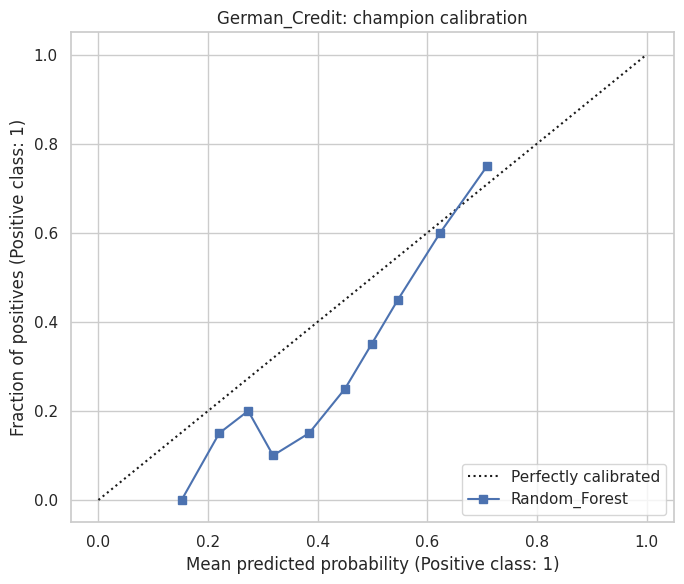

In [ ]:
plot_dataset_evaluation("German_Credit")

###Calibration for German Credit

In [ ]:
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

german_split = splits["German_Credit"]

base_rf = german_fitted_models["Random_Forest"]

calibration_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

calibrated_rf = CalibratedClassifierCV(
    estimator=clone(base_rf),
    method="sigmoid",
    cv=calibration_cv,
    n_jobs=-1
)

calibrated_rf.fit(
    german_split["X_train"],
    german_split["y_train"]
)

CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=Pipeline(steps=[('preprocess',
                                                  ColumnTransformer(transformers=[('numeric',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['duration_months',
                                                                                    'credit_amount',
                                                                                    'installment_rate',
                                                                                    'residence_since',
                                                                                    'age',
                                                                                    'existing_credi...
                                                                                    'personal_status_sex',
                                                                                    'other_debtors',
                                                                                    'property',
                                                                                    'other_installment_plans',
                                                                                    'housing',
                                                                                    'job',
                                                                                    'telephone',
                                                                                    'foreign_worker',
                                                                                    'age_band',
                                                                                    'duration_band',
                                                                                    'credit_amount_band'])])),
                                                 ('model',
                                                  RandomForestClassifier(class_weight='balanced_subsample',
                                                                         max_depth=15,
                                                                         max_features='log2',
                                                                         min_samples_leaf=5,
                                                                         min_samples_split=5,
                                                                         n_estimators=600,
                                                                         n_jobs=-1,
                                                                         random_state=42))]),
                       n_jobs=-1)

In [ ]:
from sklearn.metrics import roc_auc_score, brier_score_loss

raw_probability = base_rf.predict_proba(
    german_split["X_test"]
)[:, 1]

calibrated_probability = calibrated_rf.predict_proba(
    german_split["X_test"]
)[:, 1]

comparison = pd.DataFrame({
    "model": [
        "Random Forest",
        "Calibrated Random Forest"
    ],
    "roc_auc": [
        roc_auc_score(
            german_split["y_test"],
            raw_probability
        ),
        roc_auc_score(
            german_split["y_test"],
            calibrated_probability
        )
    ],
    "brier_score": [
        brier_score_loss(
            german_split["y_test"],
            raw_probability
        ),
        brier_score_loss(
            german_split["y_test"],
            calibrated_probability
        )
    ]
})

display(comparison)

,model,roc_auc,brier_score
0,Random Forest,0.787619,0.179613
1,Calibrated Random Forest,0.793095,0.159722


## UCI Hypothetical cost sensitivity

In [ ]:
uci_name = "UCI_Credit_Card"
uci_champion_name = champions[uci_name]
uci_champion = fitted_models[uci_name][uci_champion_name]
uci_split = splits[uci_name]

uci_oof_probability = cross_val_predict(
    clone(uci_champion), uci_split["X_train"], uci_split["y_train"],
    cv=CV, method="predict_proba", n_jobs=-1,
)[:, 1]
uci_test_probability = positive_class_scores(uci_champion, uci_split["X_test"])

uci_cost_rows = []
for fn_to_fp in [2, 5, 10]:
    candidates = []
    for threshold in np.linspace(0.01, 0.99, 99):
        pred = (uci_oof_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(uci_split["y_train"], pred, labels=[0, 1]).ravel()
        candidates.append((fn_to_fp * fn + fp, threshold))
    _, selected_threshold = min(candidates, key=lambda pair: (pair[0], -pair[1]))
    test_pred = (uci_test_probability >= selected_threshold).astype(int)
    evaluated = calculate_metrics(uci_split["y_test"], test_pred, uci_test_probability)
    uci_cost_rows.append({
        "hypothetical_fn_to_fp_ratio": f"{fn_to_fp}:1",
        "training_selected_threshold": selected_threshold,
        **evaluated,
        "hypothetical_test_cost_per_client":
            (fn_to_fp * evaluated["fn"] + evaluated["fp"]) / len(test_pred),
    })

uci_cost_sensitivity = pd.DataFrame(uci_cost_rows)
uci_cost_sensitivity.to_csv(
    OUTPUT_DIRS[uci_name]["results"] / "hypothetical_cost_sensitivity.csv", index=False
)
display(uci_cost_sensitivity)


,hypothetical_fn_to_fp_ratio,training_selected_threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,brier_score,tn,fp,fn,tp,hypothetical_test_cost_per_client
0,2:1,0.36,0.807833,0.691554,0.578520,0.483044,0.900064,0.526489,0.783461,0.562123,0.409772,0.13418,4206,467,686,641,0.3065
1,5:1,0.15,0.637000,0.694115,0.356492,0.796534,0.591697,0.492544,0.783461,0.562123,0.322278,0.13418,2765,1908,270,1057,0.5430
2,10:1,0.10,0.480500,0.633843,0.287006,0.908817,0.358870,0.436245,0.783461,0.562123,0.242515,0.13418,1677,2996,121,1206,0.7010


## German Credit documented cost-sensitive threshold

German cost-sensitive threshold: 0.20
OOF cost per applicant: 0.501


,rule,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,brier_score,tn,fp,fn,tp,documented_total_cost,documented_cost_per_applicant
0,raw_standard_0.50,0.5,0.725,0.698810,0.535211,0.633333,0.764286,0.580153,0.787619,0.653001,0.380788,0.179613,107,33,22,38,143,0.715
1,calibrated_standard_0.50,0.5,0.765,0.689286,0.638298,0.500000,0.878571,0.560748,0.792381,0.662701,0.409160,0.159353,123,17,30,30,167,0.835
2,calibrated_cost_optimized,0.2,0.620,0.680952,0.431034,0.833333,0.528571,0.568182,0.792381,0.662701,0.336020,0.159353,74,66,10,50,116,0.580


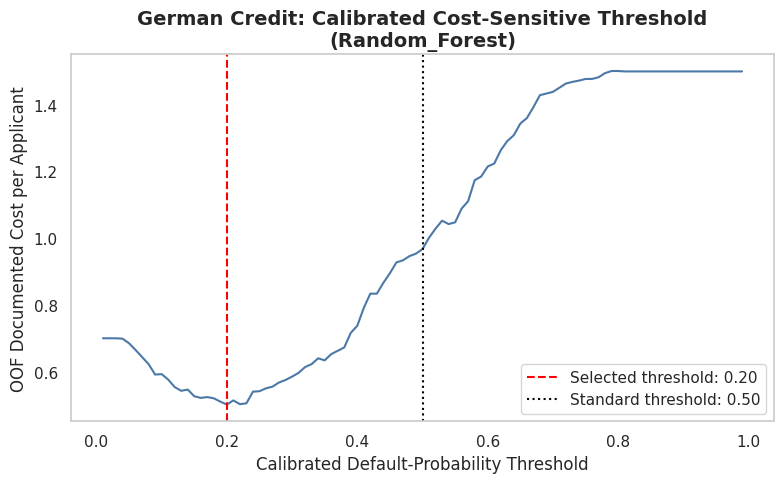

In [ ]:
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

german_name = "German_Credit"
german_champion_name = champions[german_name]

# Original champion: retain this model for SHAP
german_champion = fitted_models[
    german_name
][german_champion_name]

german_split = splits[german_name]

german_calibrated_model = CalibratedClassifierCV(
    estimator=clone(german_champion),
    method="sigmoid",
    cv=CV,
    n_jobs=1
)

german_calibrated_model.fit(
    german_split["X_train"],
    german_split["y_train"]
)

# Save calibrated decision model
joblib.dump(
    german_calibrated_model,
    OUTPUT_DIRS[german_name]["models"]
    / f"{german_champion_name}_calibrated_pipeline.joblib"
)

german_oof_probability = cross_val_predict(
    clone(german_calibrated_model),
    german_split["X_train"],
    german_split["y_train"],
    cv=CV,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_rows = []

for threshold in np.linspace(0.01, 0.99, 99):

    oof_pred = (
        german_oof_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        german_split["y_train"],
        oof_pred,
        labels=[0, 1]
    ).ravel()

    # German documented costs:
    # False positive = 1
    # False negative = 5
    documented_cost = fp + 5 * fn

    threshold_rows.append({
        "threshold": threshold,
        "oof_tn": int(tn),
        "oof_fp": int(fp),
        "oof_fn": int(fn),
        "oof_tp": int(tp),
        "oof_documented_cost": int(documented_cost),
        "oof_cost_per_applicant":
            documented_cost / len(oof_pred)
    })

german_threshold_search = pd.DataFrame(
    threshold_rows
)

# Select minimum-cost threshold.
# If costs tie, select the higher threshold.
best_threshold_row = (
    german_threshold_search
    .sort_values(
        ["oof_documented_cost", "threshold"],
        ascending=[True, False]
    )
    .iloc[0]
)

cost_threshold = float(
    best_threshold_row["threshold"]
)

print(
    f"German cost-sensitive threshold: "
    f"{cost_threshold:.2f}"
)

print(
    f"OOF cost per applicant: "
    f"{best_threshold_row['oof_cost_per_applicant']:.3f}"
)

# Original uncalibrated champion probabilities
german_raw_test_probability = positive_class_scores(
    german_champion,
    german_split["X_test"]
)

# Calibrated champion probabilities
german_calibrated_test_probability = (
    german_calibrated_model.predict_proba(
        german_split["X_test"]
    )[:, 1]
)

test_rules = [
    {
        "rule": "raw_standard_0.50",
        "probability": german_raw_test_probability,
        "threshold": 0.50
    },
    {
        "rule": "calibrated_standard_0.50",
        "probability": german_calibrated_test_probability,
        "threshold": 0.50
    },
    {
        "rule": "calibrated_cost_optimized",
        "probability": german_calibrated_test_probability,
        "threshold": cost_threshold
    }
]

threshold_comparison_rows = []

for rule in test_rules:

    probability = rule["probability"]
    threshold = rule["threshold"]

    test_pred = (
        probability >= threshold
    ).astype(int)

    evaluated = calculate_metrics(
        german_split["y_test"],
        test_pred,
        probability
    )

    documented_cost = (
        evaluated["fp"] +
        5 * evaluated["fn"]
    )

    threshold_comparison_rows.append({
        "rule": rule["rule"],
        "threshold": threshold,
        **evaluated,
        "documented_total_cost":
            documented_cost,
        "documented_cost_per_applicant":
            documented_cost / len(test_pred)
    })

german_threshold_comparison = pd.DataFrame(
    threshold_comparison_rows
)

display(german_threshold_comparison)

german_threshold_search.to_csv(
    OUTPUT_DIRS[german_name]["results"]
    / "calibrated_training_cost_threshold_search.csv",
    index=False
)

german_threshold_comparison.to_csv(
    OUTPUT_DIRS[german_name]["results"]
    / "calibrated_test_threshold_comparison.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=german_threshold_search,
    x="threshold",
    y="oof_cost_per_applicant",
    ax=ax,
    color="#4C78A8"
)

# Cost-optimised threshold
ax.axvline(
    cost_threshold,
    color="red",
    linestyle="--",
    label=f"Selected threshold: {cost_threshold:.2f}"
)

# Standard classification threshold
ax.axvline(
    0.50,
    color="black",
    linestyle=":",
    label="Standard threshold: 0.50"
)

ax.set_xlabel("Calibrated Default-Probability Threshold")
ax.set_ylabel("OOF Documented Cost per Applicant")

ax.set_title(
    f"German Credit: Calibrated Cost-Sensitive Threshold\n"
    f"({german_champion_name})",
    fontsize=14,
    fontweight="bold"
)

ax.legend()
ax.grid(False)

save_and_show(
    OUTPUT_DIRS[german_name]["figures"]
    / "calibrated_cost_sensitive_threshold.png"
)

Probability calibration improved the Random Forest’s Brier score from 0.180 to 0.159, indicating more reliable probability estimates. Lowering the decision threshold from 0.50 to the cost-optimised value of 0.20 increased default recall from 0.500 to 0.833, reducing false negatives from 30 to 10. However, false positives increased from 17 to 66, lowering precision and accuracy. This trade-off is appropriate when failing to identify a defaulter is substantially more costly than incorrectly rejecting a non-defaulter. Therefore, 0.20 was retained as the operational cost-sensitive threshold, while 0.50 remains preferable when overall accuracy is prioritised.

## SHAP explanations for each independently selected champion

In [ ]:
TREE_MODEL_NAMES = {"Random_Forest", "XGBoost", "LightGBM"}


def stratified_indices(y, n, seed=RANDOM_STATE):
    y = pd.Series(y)
    if len(y) <= n:
        return y.index.to_numpy()
    chosen, _ = train_test_split(
        y.index.to_numpy(), train_size=n, stratify=y.to_numpy(), random_state=seed
    )
    return np.asarray(chosen)


def to_dense(matrix):
    return matrix.toarray() if sparse.issparse(matrix) else np.asarray(matrix)


def positive_class_explanation(raw_explanation, data, feature_names, expected_value=None):
    # Normalize SHAP's different binary-class return shapes.
    if isinstance(raw_explanation, list):
        values = np.asarray(raw_explanation[1])
        base = expected_value[1] if np.ndim(expected_value) else expected_value
    else:
        values = np.asarray(raw_explanation.values)
        base_values = np.asarray(raw_explanation.base_values)
        if values.ndim == 3:
            values = values[:, :, 1]
            if base_values.ndim >= 2:
                base = base_values[:, 1]
            elif base_values.ndim == 1 and len(base_values) == 2:
                base = base_values[1]
            else:
                base = base_values
        else:
            base = base_values

    if np.ndim(base) == 0:
        base = np.repeat(float(base), len(values))
    elif np.asarray(base).shape == (2,):
        base = np.repeat(float(np.asarray(base)[1]), len(values))

    return shap.Explanation(
        values=values,
        base_values=base,
        data=data,
        feature_names=list(feature_names),
    )


def source_feature_name(transformed_name, numeric_features, categorical_features):
    clean = transformed_name.split("__", 1)[-1]
    if clean in numeric_features:
        return clean
    for column in sorted(categorical_features, key=len, reverse=True):
        if clean == column or clean.startswith(f"{column}_"):
            return column
    return clean

In [ ]:
def explain_champion(
    dataset_name,
    decision_model=None,
    decision_threshold=0.50
):
    champion_name = champions[dataset_name]

    # Original champion pipeline used for SHAP
    pipeline = fitted_models[dataset_name][champion_name]
    split = splits[dataset_name]

    # Model used to make the final decision
    if decision_model is None:
        decision_model = pipeline

    preprocessor = pipeline.named_steps["preprocess"]
    model = pipeline.named_steps["model"]

    is_fast_explainer = (
        champion_name in TREE_MODEL_NAMES
        or champion_name == "Logistic_Regression"
    )

    background_n = 100 if is_fast_explainer else 50
    explain_n = (
        (500 if FAST_MODE else 1_000)
        if is_fast_explainer
        else (60 if FAST_MODE else 150)
    )

    # Select representative training and test observations
    background_idx = stratified_indices(
        split["y_train"],
        background_n
    )

    explain_idx = stratified_indices(
        split["y_test"],
        explain_n,
        seed=RANDOM_STATE + 1
    )

    X_background = split["X_train"].loc[background_idx]
    X_explain = split["X_test"].loc[explain_idx]
    y_explain = split["y_test"].loc[explain_idx]

    # Apply the fitted preprocessing steps
    background_t = to_dense(
        preprocessor.transform(X_background)
    )

    explain_t = to_dense(
        preprocessor.transform(X_explain)
    )

    feature_names = preprocessor.get_feature_names_out()

    print(
        f"Explaining {dataset_name} champion {champion_name}: "
        f"{len(explain_t)} cases, "
        f"{explain_t.shape[1]} transformed features"
    )

  # Create Shap Analysis
    if champion_name in TREE_MODEL_NAMES:
        explainer = shap.TreeExplainer(model)

        try:
            raw = explainer(
                explain_t,
                check_additivity=False
            )
        except TypeError:
            raw = explainer(explain_t)

        explanation = positive_class_explanation(
            raw,
            explain_t,
            feature_names,
            getattr(explainer, "expected_value", None)
        )

    elif champion_name == "Logistic_Regression":
        explainer = shap.LinearExplainer(
            model,
            background_t
        )

        raw = explainer(explain_t)

        explanation = positive_class_explanation(
            raw,
            explain_t,
            feature_names,
            getattr(explainer, "expected_value", None)
        )

    else:
        def predict_default(transformed):
            return model.predict_proba(transformed)[:, 1]

        masker = shap.maskers.Independent(
            background_t,
            max_samples=len(background_t)
        )

        explainer = shap.Explainer(
            predict_default,
            masker=masker,
            algorithm="permutation",
            feature_names=list(feature_names)
        )

        min_evals = 2 * explain_t.shape[1] + 1

        raw = explainer(
            explain_t,
            max_evals=max(500, min_evals),
            batch_size=20
        )

        explanation = positive_class_explanation(
            raw,
            explain_t,
            feature_names
        )

    #Global SHAP plots
    shap.plots.beeswarm(
        explanation,
        max_display=20,
        show=False
    )

    plt.title(
        f"{dataset_name}: {champion_name} SHAP beeswarm"
    )

    save_and_show(
        OUTPUT_DIRS[dataset_name]["shap"]
        / f"{champion_name}_SHAP_beeswarm.png"
    )

    shap.plots.bar(
        explanation,
        max_display=20,
        show=False
    )

    plt.title(
        f"{dataset_name}: {champion_name} mean |SHAP|"
    )

    save_and_show(
        OUTPUT_DIRS[dataset_name]["shap"]
        / f"{champion_name}_SHAP_global_bar.png"
    )

  #local shap waterfall plot
    shap.plots.waterfall(
        explanation[0],
        max_display=15,
        show=False
    )

    plt.title(
        f"{dataset_name}: {champion_name} local explanation"
    )

    save_and_show(
        OUTPUT_DIRS[dataset_name]["shap"]
        / f"{champion_name}_SHAP_waterfall_case_1.png"
    )

#transformed feature importance
    transformed_importance = pd.DataFrame({
        "transformed_feature": feature_names,
        "mean_abs_shap": np.abs(
            explanation.values
        ).mean(axis=0)
    }).sort_values(
        "mean_abs_shap",
        ascending=False
    )

    transformed_importance["source_feature"] = (
        transformed_importance["transformed_feature"].map(
            lambda name: source_feature_name(
                name,
                split["numeric_features"],
                split["categorical_features"]
            )
        )
    )

    # Combine one-hot encoded features back into original features
    grouped_importance = (
        transformed_importance
        .groupby(
            "source_feature",
            as_index=False
        )["mean_abs_shap"]
        .sum()
        .sort_values(
            "mean_abs_shap",
            ascending=False
        )
    )

    transformed_importance.to_csv(
        OUTPUT_DIRS[dataset_name]["shap"]
        / f"{champion_name}_transformed_feature_importance.csv",
        index=False
    )

    grouped_importance.to_csv(
        OUTPUT_DIRS[dataset_name]["shap"]
        / f"{champion_name}_grouped_source_feature_importance.csv",
        index=False
    )

 # local explanation for the first five example
    local_rows = []

    for position in range(min(5, len(explanation))):
        case = X_explain.iloc[[position]]

        # Probability from original champion
        base_probability = float(
            positive_class_scores(
                pipeline,
                case
            )[0]
        )

        # Calibrated probability when a calibrated model is supplied
        decision_probability = float(
            positive_class_scores(
                decision_model,
                case
            )[0]
        )

        # Apply the selected decision threshold
        predicted_class = int(
            decision_probability >= decision_threshold
        )

        # Select the 15 largest absolute SHAP contributions
        order = np.argsort(
            np.abs(explanation.values[position])
        )[::-1][:15]

        for rank, feature_position in enumerate(
            order,
            start=1
        ):
            local_rows.append({
                "source_row_index":
                    X_explain.index[position],

                "actual_default":
                    int(y_explain.iloc[position]),

                "base_model_probability":
                    base_probability,

                "decision_probability":
                    decision_probability,

                "decision_threshold":
                    float(decision_threshold),

                "predicted_default_class":
                    predicted_class,

                "rank":
                    rank,

                "transformed_feature":
                    feature_names[feature_position],

                "transformed_value":
                    explanation.data[
                        position,
                        feature_position
                    ],

                "shap_contribution":
                    explanation.values[
                        position,
                        feature_position
                    ]
            })

    local_explanations = pd.DataFrame(local_rows)

    local_explanations.to_csv(
        OUTPUT_DIRS[dataset_name]["shap"]
        / f"{champion_name}_local_explanations.csv",
        index=False
    )

    print("Top grouped source features:")
    display(grouped_importance.head(15))

    return {
        "explanation": explanation,
        "transformed_importance": transformed_importance,
        "grouped_importance": grouped_importance,
        "local_explanations": local_explanations,
        "explained_indices": X_explain.index.tolist(),
        "decision_threshold": decision_threshold
    }

Explaining UCI_Credit_Card champion XGBoost: 500 cases, 46 transformed features


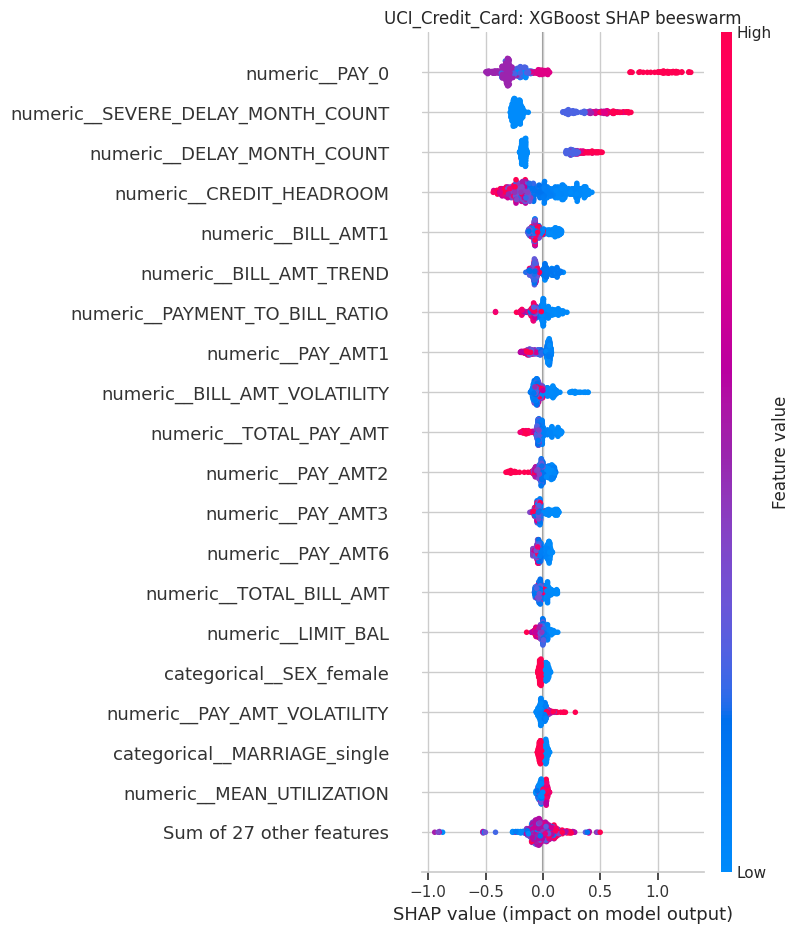

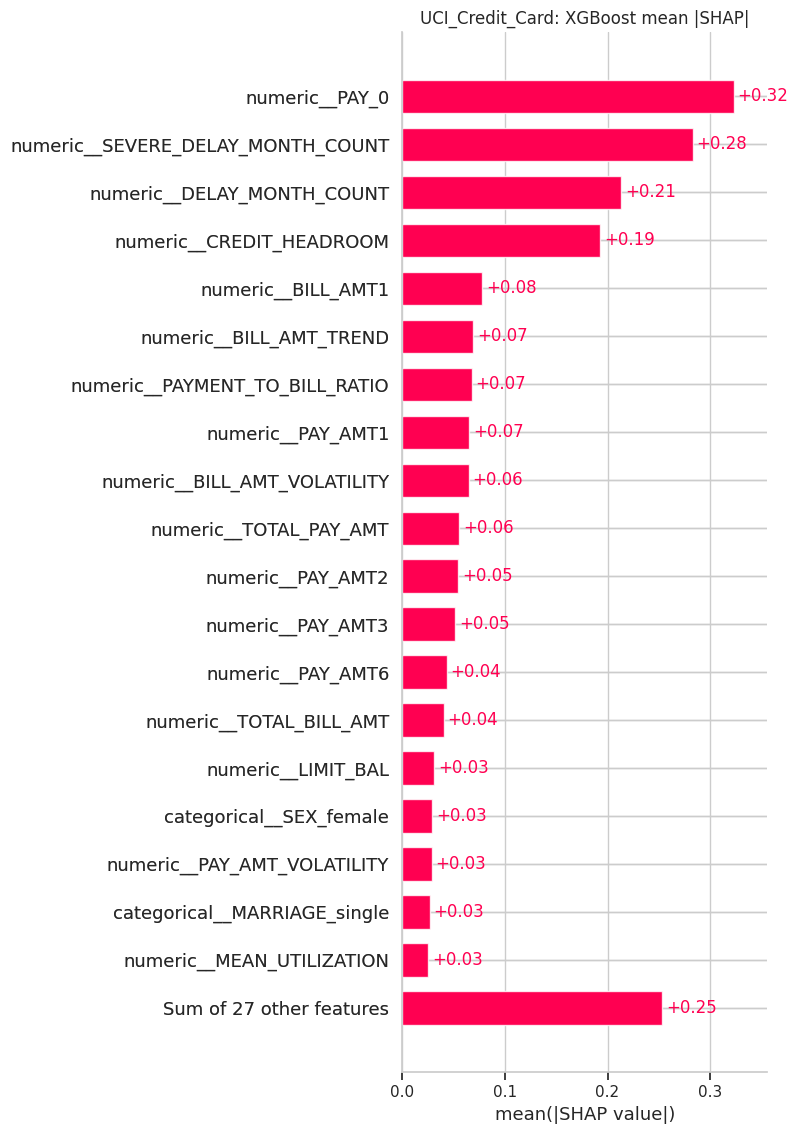

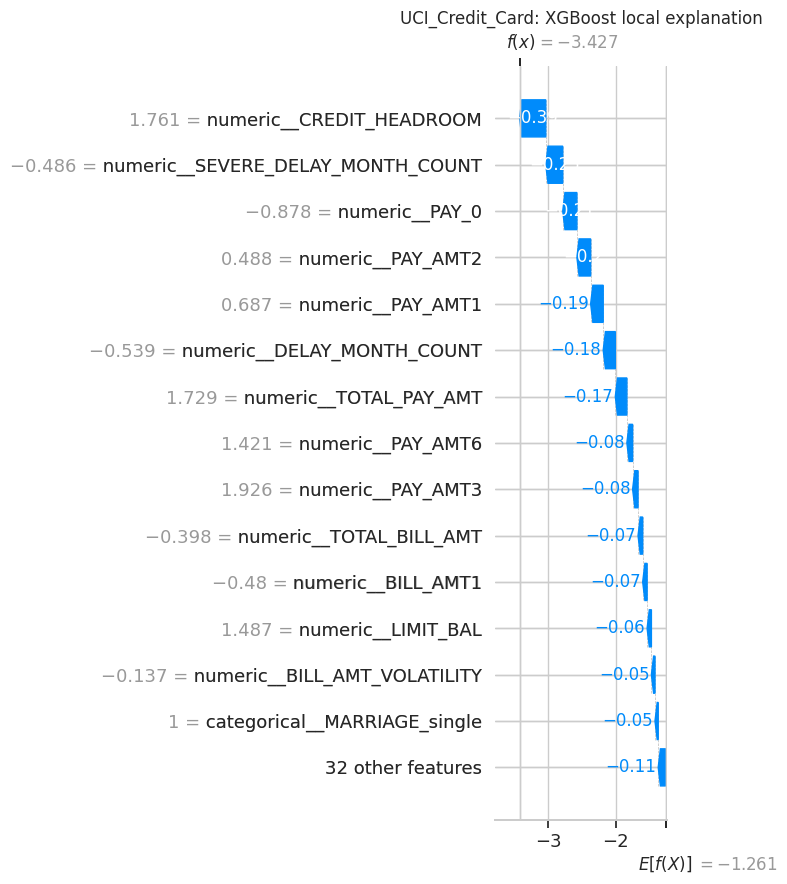

Top grouped source features:


,source_feature,mean_abs_shap
21,PAY_0,0.322872
36,SEVERE_DELAY_MONTH_COUNT,0.283136
11,DELAY_MONTH_COUNT,0.213560
9,CREDIT_HEADROOM,0.192894
1,BILL_AMT1,0.077753
7,BILL_AMT_TREND,0.068828
20,PAYMENT_TO_BILL_RATIO,0.067648
27,PAY_AMT1,0.065145
8,BILL_AMT_VOLATILITY,0.064581
39,TOTAL_PAY_AMT,0.055162


In [ ]:
uci_shap_results = explain_champion("UCI_Credit_Card")

Explaining German_Credit champion Random_Forest: 200 cases, 80 transformed features


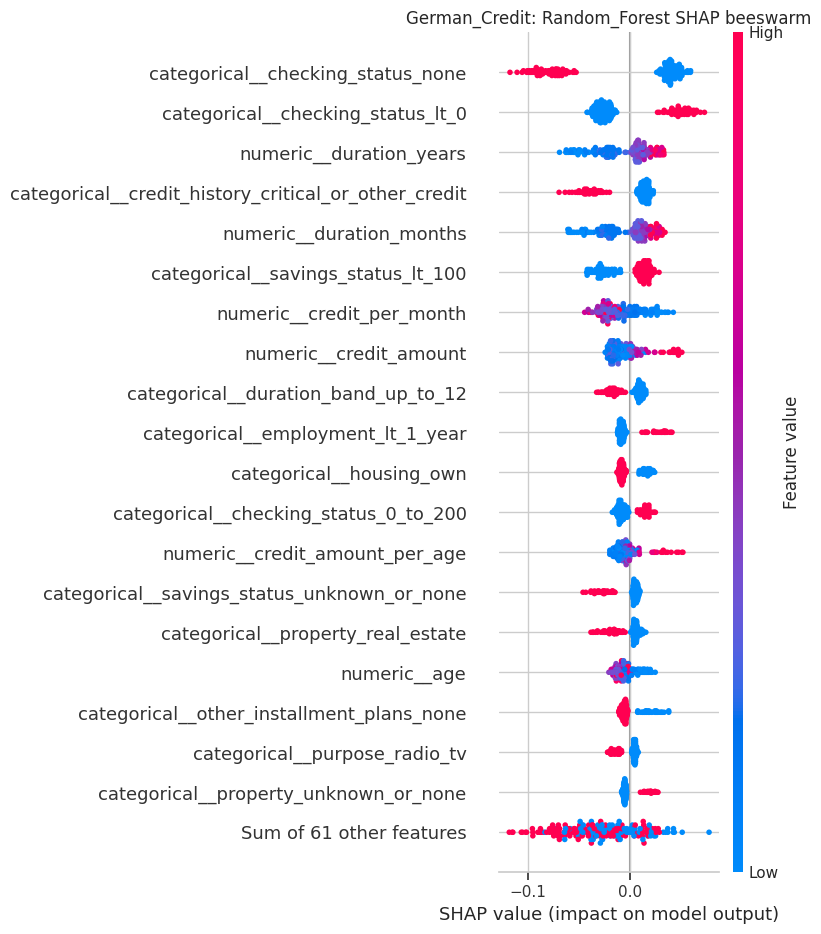

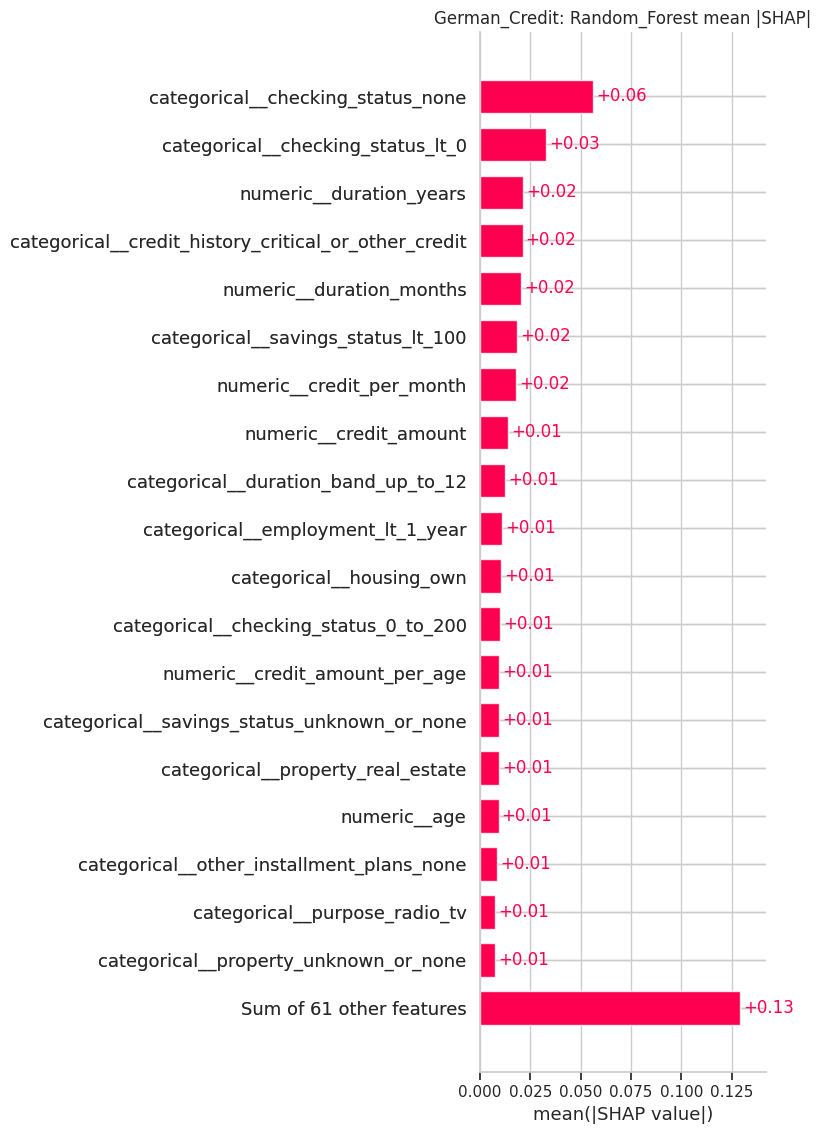

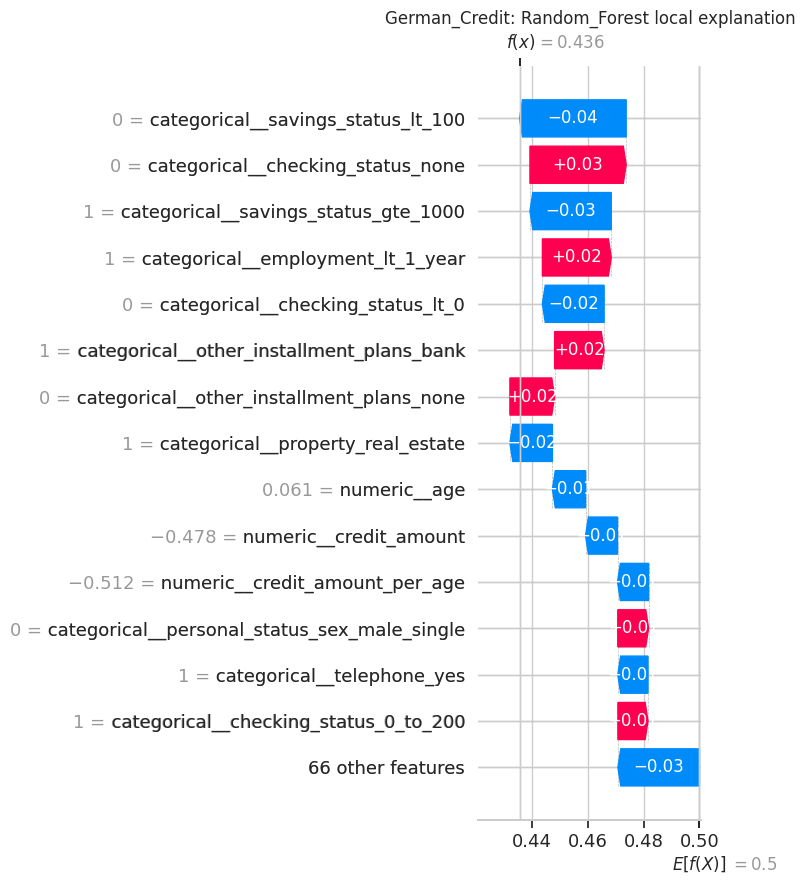

Top grouped source features:


,source_feature,mean_abs_shap
2,checking_status,0.099995
25,savings_status,0.031811
6,credit_history,0.029651
23,purpose,0.022741
10,duration_years,0.021437
11,employment,0.020658
9,duration_months,0.020351
22,property,0.019255
8,duration_band,0.018451
7,credit_per_month,0.017827


In [ ]:
german_shap_results = explain_champion("German_Credit")
shap_results = {"UCI_Credit_Card": uci_shap_results, "German_Credit": german_shap_results}

## Cross-experiment Methodological replication

In [ ]:
rank_table = metrics.copy()
rank_table["cv_rank"] = rank_table.groupby("dataset")["cv_roc_auc_mean"].rank(
    method="average", ascending=False
)
rank_pivot = rank_table.pivot(index="model", columns="dataset", values="cv_rank")
rank_pivot.to_csv(COMPARISON_DIR / "model_cv_rank_comparison.csv")

common = rank_pivot.dropna()
tau, tau_p = kendalltau(common["UCI_Credit_Card"], common["German_Credit"])
replication_summary = pd.DataFrame([{
    "comparison": "CV model-family ranking",
    "n_model_families": len(common),
    "kendall_tau": tau,
    "p_value": tau_p,
    "interpretation": (
        "more similar rankings" if tau > 0.5 else
        "moderately similar rankings" if tau > 0 else
        "different rankings"
    ),
}])
replication_summary.to_csv(COMPARISON_DIR / "methodological_replication_summary.csv", index=False)

display(rank_pivot)
display(replication_summary)
print(
    "Interpret cautiously: the datasets represent different products, populations, eras and "
    "prediction contexts. Ranking agreement assesses methodological replication, not transport "
    "of a fitted model."
)


dataset,German_Credit,UCI_Credit_Card
model,,
Dummy,8.0,8.0
KNN,6.0,7.0
LightGBM,3.0,2.0
Logistic_Regression,7.0,5.0
MLP,5.0,4.0
Random_Forest,1.0,3.0
SVM,4.0,6.0
XGBoost,2.0,1.0


,comparison,n_model_families,kendall_tau,p_value,interpretation
0,CV model-family ranking,8,0.642857,0.031151,more similar rankings


Interpret cautiously: the datasets represent different products, populations, eras and prediction contexts. Ranking agreement assesses methodological replication, not transport of a fitted model.


Model-family rankings showed moderately strong and statistically significant agreement between the German Credit and UCI Credit Card datasets (Kendall’s \(\tau = 0.643\), \(p = 0.031\)). Tree-based ensemble models consistently occupied the highest-ranking positions, although the best-performing model differed: Random Forest ranked first for German Credit, whereas XGBoost ranked first for UCI Credit Card.

In [ ]:
manifest = {
    "project_design": {
        "primary_experiment": "UCI_Credit_Card",
        "independent_replication": "German_Credit",
        "replication_scope": "methodology, not fitted-model external validation",
    },
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "fast_mode": FAST_MODE,
    "run_robustness": RUN_ROBUSTNESS,
    "run_heavy_learning_curves": RUN_HEAVY_LEARNING_CURVES,
    "cv_splits": CV_SPLITS,
    "search_iterations": SEARCH_ITERATIONS,
    "primary_selection_metric": PRIMARY_METRIC,
    "decision_threshold": 0.50,
    "champions": champions,
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgb.__version__,
        "lightgbm": lgb.__version__,
        "shap": shap.__version__,
    },
}
with open(COMPARISON_DIR / "reproducibility_manifest.json", "w") as handle:
    json.dump(manifest, handle, indent=2)

artifact_rows = []
for path in sorted(OUTPUT_ROOT.rglob("*")):
    if path.is_file():
        artifact_rows.append({
            "relative_path": str(path.relative_to(OUTPUT_ROOT)),
            "size_kb": round(path.stat().st_size / 1024, 2),
        })
artifact_index = pd.DataFrame(artifact_rows)
artifact_index.to_csv(COMPARISON_DIR / "artifact_index.csv", index=False)
display(artifact_index)

print("Project complete.")
print("Saved outputs:", OUTPUT_ROOT)


,relative_path,size_kb
0,cross_experiment_comparison/all_model_metrics.csv,8.16
1,cross_experiment_comparison/champion_model_sum...,1.55
2,cross_experiment_comparison/data_quality_summa...,0.17
3,cross_experiment_comparison/feature_engineerin...,0.08
4,cross_experiment_comparison/methodological_rep...,0.15
...,...,...
106,uci_primary/shap/XGBoost_SHAP_global_bar.png,221.49
107,uci_primary/shap/XGBoost_SHAP_waterfall_case_1...,205.99
108,uci_primary/shap/XGBoost_grouped_source_featur...,0.96
109,uci_primary/shap/XGBoost_local_explanations.csv,8.13


Project complete.
Saved outputs: /content/drive/MyDrive/Credit_Risk_Prediction/outputs


In [98]:
from pathlib import Path

MODEL_PATH = Path(
    "/content/drive/MyDrive/"
    "Credit_Default_Streamlit/"
    "credit_models.joblib"
)

print("Model bundle exists:", MODEL_PATH.exists())

Model bundle exists: True


## Deployment

In [ ]:
!pip install -q streamlit

In [112]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [113]:
from pathlib import Path
import shutil

DRIVE_ROOT = Path("/content/drive/MyDrive")

DEPLOY_DIR = (
    DRIVE_ROOT / "Credit_Default_Streamlit"
)

DEPLOY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = (
    DEPLOY_DIR / "credit_models.joblib"
)

if MODEL_PATH.exists():
    print("Model bundle found:")
    print(MODEL_PATH)

else:
    print("Searching Google Drive...")

    candidates = list(
        DRIVE_ROOT.rglob("credit_models.joblib")
    )

    if candidates:
        print("Found these files:")

        for position, path in enumerate(candidates):
            print(position, path)

        # Copy the first matching file into the deployment folder
        shutil.copy2(
            candidates[0],
            MODEL_PATH
        )

        print("\nCopied model bundle to:")
        print(MODEL_PATH)

    else:
        print(
            "No credit_models.joblib file was found."
        )

Model bundle found:
/content/drive/MyDrive/Credit_Default_Streamlit/credit_models.joblib


In [114]:
print("Model exists:", MODEL_PATH.exists())
print("Model size:", MODEL_PATH.stat().st_size if MODEL_PATH.exists() else 0)

Model exists: True
Model size: 7534082


In [115]:
import subprocess
import sys

REQUIREMENTS_PATH = (
    DEPLOY_DIR / "requirements.txt"
)

if REQUIREMENTS_PATH.exists():
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "-r",
            str(REQUIREMENTS_PATH)
        ],
        check=True
    )

else:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "streamlit",
            "shap",
            "xgboost",
            "scikit-learn",
            "imbalanced-learn",
            "joblib",
            "matplotlib",
            "pandas",
            "numpy"
        ],
        check=True
    )

print("Dependencies installed.")

Dependencies installed.


In [116]:
import joblib

deployment_bundle = joblib.load(
    MODEL_PATH
)

print("Bundle type:", type(deployment_bundle))
print("Datasets:", list(deployment_bundle.keys()))

for dataset_name, information in deployment_bundle.items():
    print("\nDataset:", dataset_name)
    print("Champion:", information["champion_name"])
    print("Threshold:", information["threshold"])
    print("Calibrated:", information["calibrated"])
    print(
        "Number of input features:",
        len(information["input_schema"])
    )

Bundle type: <class 'dict'>
Datasets: ['UCI_Credit_Card', 'German_Credit']

Dataset: UCI_Credit_Card
Champion: XGBoost
Threshold: 0.5
Calibrated: False
Number of input features: 40

Dataset: German_Credit
Champion: Random_Forest
Threshold: 0.2
Calibrated: True
Number of input features: 27


In [117]:
%%writefile /content/drive/MyDrive/Credit_Default_Streamlit/app.py

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import streamlit as st


st.set_page_config(
    page_title="Credit Default Risk",
    page_icon="💳",
    layout="wide"
)

st.title("Credit Default Risk Prediction")

st.caption(
    "Explainable prediction using the UCI Credit Card "
    "and German Credit datasets."
)

APP_DIR = Path(__file__).resolve().parent
MODEL_PATH = APP_DIR / "credit_models.joblib"


@st.cache_resource
def load_bundle():
    return joblib.load(MODEL_PATH)


# Show errors on the page rather than producing a blank page
try:
    bundle = load_bundle()

except Exception as error:
    st.error("The model bundle could not be loaded.")
    st.exception(error)
    st.stop()


if not bundle:
    st.error("The model bundle is empty.")
    st.stop()


st.sidebar.success("Application started successfully")


dataset_name = st.sidebar.selectbox(
    "Select dataset",
    options=list(bundle.keys()),
    format_func=lambda name: bundle[name].get(
        "display_name",
        name
    )
)

information = bundle[dataset_name]

required_items = [
    "champion_name",
    "decision_model",
    "explanation_model",
    "threshold",
    "input_schema"
]

missing_items = [
    item
    for item in required_items
    if item not in information
]

if missing_items:
    st.error(
        f"Missing bundle items: {missing_items}"
    )
    st.stop()


champion_name = information["champion_name"]
decision_model = information["decision_model"]
explanation_model = information["explanation_model"]
threshold = float(information["threshold"])
schema = information["input_schema"]


st.sidebar.markdown(
    f"""
    **Champion model:** {champion_name}
    **Decision threshold:** {threshold:.2f}
    **Calibrated:** {
        "Yes"
        if information.get("calibrated", False)
        else "No"
    }
    """
)


include_shap = st.sidebar.checkbox(
    "Generate SHAP explanation",
    value=True
)


def create_input_form(input_schema):
    values = {}

    left_column, right_column = st.columns(2)
    layout_columns = [left_column, right_column]

    for position, feature in enumerate(input_schema):
        column = layout_columns[position % 2]

        feature_name = feature["name"]
        feature_type = feature["type"]

        with column:
            if feature_type == "categorical":
                options = feature.get(
                    "options",
                    []
                )

                if not options:
                    st.warning(
                        f"No options available for "
                        f"{feature_name}"
                    )
                    values[feature_name] = None
                    continue

                default = feature.get(
                    "default",
                    options[0]
                )

                default_position = (
                    options.index(default)
                    if default in options
                    else 0
                )

                values[feature_name] = st.selectbox(
                    feature_name,
                    options=options,
                    index=default_position
                )

            elif feature_type == "integer":
                values[feature_name] = st.number_input(
                    feature_name,
                    value=int(
                        feature.get("default", 0)
                    ),
                    step=1
                )

            else:
                values[feature_name] = st.number_input(
                    feature_name,
                    value=float(
                        feature.get("default", 0.0)
                    ),
                    format="%.4f"
                )

    return pd.DataFrame(
        [values],
        columns=[
            feature["name"]
            for feature in input_schema
        ]
    )


def calculate_local_shap(
    pipeline,
    input_row
):
    preprocessor = pipeline.named_steps[
        "preprocess"
    ]

    tree_model = pipeline.named_steps[
        "model"
    ]

    transformed = preprocessor.transform(
        input_row
    )

    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()

    feature_names = (
        preprocessor.get_feature_names_out()
    )

    explainer = shap.TreeExplainer(
        tree_model
    )

    try:
        raw_explanation = explainer(
            transformed,
            check_additivity=False
        )

    except TypeError:
        raw_explanation = explainer(
            transformed
        )

    shap_values = np.asarray(
        raw_explanation.values
    )

    # Binary classifiers may return:
    # (rows, features, classes)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    local_importance = pd.DataFrame({
        "feature": feature_names,
        "shap_contribution": shap_values[0]
    })

    local_importance["absolute_contribution"] = (
        local_importance[
            "shap_contribution"
        ].abs()
    )

    return local_importance.sort_values(
        "absolute_contribution",
        ascending=False
    )


with st.form("prediction_form"):
    st.subheader("Applicant information")

    input_row = create_input_form(
        schema
    )

    submitted = st.form_submit_button(
        "Predict default risk",
        type="primary"
    )


if submitted:
    try:
        probability = float(
            decision_model.predict_proba(
                input_row
            )[0, 1]
        )

        predicted_class = int(
            probability >= threshold
        )

    except Exception as error:
        st.error("Prediction could not be generated.")
        st.exception(error)
        st.stop()

    st.subheader("Prediction result")

    result_column_1, result_column_2, result_column_3 = (
        st.columns(3)
    )

    result_column_1.metric(
        "Default probability",
        f"{probability:.1%}"
    )

    result_column_2.metric(
        "Decision threshold",
        f"{threshold:.1%}"
    )

    result_column_3.metric(
        "Model classification",
        (
            "Higher default risk"
            if predicted_class == 1
            else "Lower default risk"
        )
    )

    st.progress(
        probability,
        text=(
            "Estimated default probability: "
            f"{probability:.1%}"
        )
    )

    if predicted_class == 1:
        st.warning(
            "The predicted probability exceeds "
            "the selected decision threshold."
        )

    else:
        st.success(
            "The predicted probability is below "
            "the selected decision threshold."
        )

    with st.expander("Show submitted data"):
        st.dataframe(
            input_row,
            use_container_width=True
        )

    if include_shap:
        st.subheader("Local SHAP explanation")

        try:
            local_importance = (
                calculate_local_shap(
                    explanation_model,
                    input_row
                )
                .head(12)
                .sort_values(
                    "shap_contribution"
                )
            )

            colors = np.where(
                local_importance[
                    "shap_contribution"
                ] >= 0,
                "#D62728",
                "#4C78A8"
            )

            figure, axis = plt.subplots(
                figsize=(9, 6)
            )

            axis.barh(
                local_importance["feature"],
                local_importance[
                    "shap_contribution"
                ],
                color=colors,
                edgecolor="black"
            )

            axis.axvline(
                0,
                color="black",
                linewidth=1
            )

            axis.set_xlabel(
                "SHAP contribution to model output"
            )

            axis.set_ylabel("")

            axis.set_title(
                f"Local explanation: "
                f"{champion_name}"
            )

            st.pyplot(figure)

            plt.close(figure)

            st.caption(
                "Red features increase the model output "
                "towards default; blue features decrease it."
            )

            if information.get(
                "calibrated",
                False
            ):
                st.info(
                    "The displayed German Credit probability "
                    "comes from the calibrated model. SHAP "
                    "explains the underlying Random Forest."
                )

        except Exception as error:
            st.warning(
                "The prediction was successful, but the "
                "SHAP explanation could not be generated."
            )

            st.exception(error)


st.divider()

st.caption(
    "Academic prototype only. The result should not be "
    "used as the sole basis for a real lending decision."
)

Overwriting /content/drive/MyDrive/Credit_Default_Streamlit/app.py


In [118]:
APP_FILE = (
    DEPLOY_DIR / "app.py"
)

print("App exists:", APP_FILE.exists())
print("Model exists:", MODEL_PATH.exists())

print("\nDeployment directory:")

for path in DEPLOY_DIR.iterdir():
    print("-", path.name)

App exists: True
Model exists: True

Deployment directory:
- credit_models.joblib
- app.py


In [119]:
import subprocess
import sys
import time
from pathlib import Path

# Stop the old process on port 8501
subprocess.run(
    ["fuser", "-k", "8501/tcp"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

STREAMLIT_LOG = Path(
    "/content/streamlit.log"
)

log_file = open(
    STREAMLIT_LOG,
    "w"
)

streamlit_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        str(APP_FILE),
        "--server.address",
        "0.0.0.0",
        "--server.port",
        "8501",
        "--server.headless",
        "true",
        "--server.enableCORS",
        "false",
        "--server.enableXsrfProtection",
        "false",
        "--browser.gatherUsageStats",
        "false"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("Streamlit process:", streamlit_process.pid)
print(STREAMLIT_LOG.read_text())

Streamlit process: 94919
2026-08-30 15:09:08.847 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.66.38.27:8501




In [120]:
import requests

try:
    response = requests.get(
        "http://localhost:8501",
        timeout=20
    )

    print("HTTP status:", response.status_code)
    print("Response length:", len(response.text))

except Exception as error:
    print("Streamlit is not responding:")
    print(error)

    print("\nStreamlit log:")
    print(STREAMLIT_LOG.read_text())

HTTP status: 200
Response length: 11141


In [121]:
!wget -q \
https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
-O /usr/local/bin/cloudflared

!chmod +x /usr/local/bin/cloudflared

!cloudflared --version

cloudflared version 2026.8.2 (built 2026-08-14-12:17 UTC)


In [122]:
import re
import subprocess
import time
from pathlib import Path
from IPython.display import HTML, display

subprocess.run(
    ["pkill", "cloudflared"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

CLOUDFLARE_LOG = Path(
    "/content/cloudflared.log"
)

tunnel_log_file = open(
    CLOUDFLARE_LOG,
    "w"
)

tunnel_process = subprocess.Popen(
    [
        "cloudflared",
        "tunnel",
        "--url",
        "http://localhost:8501",
        "--no-autoupdate"
    ],
    stdout=tunnel_log_file,
    stderr=subprocess.STDOUT
)

public_url = None

for _ in range(30):
    time.sleep(1)

    log_text = CLOUDFLARE_LOG.read_text()

    match = re.search(
        r"https://[a-zA-Z0-9-]+\.trycloudflare\.com",
        log_text
    )

    if match:
        public_url = match.group(0)
        break

if public_url:
    print("Open this Streamlit URL:")
    print(public_url)

    display(
        HTML(
            f'<a href="{public_url}" target="_blank">'
            f'Open Credit Default Streamlit App'
            f'</a>'
        )
    )

else:
    print("A public URL was not generated.")
    print(CLOUDFLARE_LOG.read_text())

Open this Streamlit URL:
https://dialog-merger-count-fusion.trycloudflare.com


## Conclusion

This project developed dataset-specific and explainable credit-risk models with satisfactory discriminatory performance. XGBoost was selected for UCI Credit Card (test ROC–AUC = 0.7835), while Random Forest was selected for German Credit (test ROC–AUC = 0.7876). Their small cross-validation-to-test performance gaps indicate reasonable generalisation with limited evidence of overfitting.


SHAP analysis showed that UCI predictions were driven primarily by recent repayment status (PAY_0), delayed-payment frequency, available credit headroom, bill amounts and payment behaviour. For German Credit, checking-account status was the dominant feature, followed by savings status, credit history, loan purpose and repayment duration. These findings indicate that repayment behaviour and financial capacity were more influential than most demographic characteristics. However, SHAP importance represents model reliance rather than causal effects.


Finally, calibration improved probability reliability, while lowering the German Credit decision threshold to 0.20 increased default recall from 0.500 to 0.833 and reduced false negatives from 30 to 10. Overall, the project demonstrates that effective credit-risk assessment requires not only predictive performance, but also probability calibration, cost-sensitive threshold selection and transparent explanation of model decisions. Sensitive variables such as marital status and personal status/sex should nevertheless undergo fairness assessment before real-world deployment.

## Reference

Aruleba, I., & Sun, Y. (2025a). An improved ensemble method with data resampling for credit risk prediction. IEEE Access, 13, 71275–71287. https://doi.org/10.1109/ACCESS.2025.3563432

Aruleba, I., & Sun, Y. (2025b). Enhanced credit risk prediction using deep learning and SMOTE-ENN resampling. Machine Learning with Applications, 21, 100692. https://doi.org/10.1016/j.mlwa.2025.100692

Ben Ghozzi, S., Ben HajKacem, M. A., & Essoussi, N. (2024). Explainable ensemble machine learning method for credit risk classification. In 2024 International Conference on INnovations in Intelligent SysTems and Applications (INISTA). IEEE. https://doi.org/10.1109/INISTA62901.2024.10683830

Bitetto, A., Cerchiello, P., Filomeni, S., Tanda, A., & Tarantino, B. (2024). Can we trust machine learning to predict the credit risk of small businesses? Review of Quantitative Finance and Accounting, 63(3), 925–954. https://doi.org/10.1007/s11156-024-01278-0

Bracke, P., Datta, A., Jung, C., & Sen, S. (2019). Machine learning explainability in finance: An application to default risk analysis (Staff Working Paper No. 816). Bank of England. https://www.bankofengland.co.uk/working-paper/2019/machine-learning-explainability-in-finance-an-application-to-default-risk-analysis

Bussmann, N., Giudici, P., Marinelli, D., & Papenbrock, J. (2021). Explainable machine learning in credit risk management. Computational Economics, 57(1), 203–216. https://doi.org/10.1007/s10614-020-10042-0

Chang, V., Xu, Q. A., Akinloye, S. H., Benson, V., & Hall, K. (2025). Prediction of bank credit worthiness through credit risk analysis: An explainable machine learning study. Annals of Operations Research, 354(1), 247–271. https://doi.org/10.1007/s10479-024-06134-x

Chen, A., & Qiu, Y. (2024). Deep learning and machine learning models for scalable credit card default prediction on big data. In 2024 IEEE International Conference on Big Data (BigData) (pp. 7292–7296). IEEE. https://doi.org/10.1109/BigData62323.2024.10825743

Cil, A. E., & Yildiz, K. (2025). A systematic literature review on applications of explainable artificial intelligence in the financial sector. Internet of Things, 33, 101696. https://doi.org/10.1016/j.iot.2025.101696

Le, H.-S., Le, Q. C. P., Truong, C. V., Ho, M. M. N., & Lee, J.-H. (2025). Default prediction in the finance industry based on ensemble learning: Combining machine learning and deep learning. Business Systems Research, 16(1), 198–218. https://doi.org/10.2478/bsrj-2025-0010

Lee, J., Lee, Y., Hong, J., Chung, Y., & Kim, E. (2026). Hybrid CNN-transformer architecture for personal credit risk prediction with comparative insights into model explainability. The Journal of Supercomputing, 82, 316. https://doi.org/10.1007/s11227-026-08486-6

Li, H., & Wu, W. (2024). Loan default predictability with explainable machine learning. Finance Research Letters, 60, 104867. https://doi.org/10.1016/j.frl.2023.104867

Li, Y., Zhao, R., & An, Y. (2026). A credit risk prediction model combining ensemble learning and deep learning through three-way decisions. Journal of Big Data, 13, 44. https://doi.org/10.1186/s40537-026-01375-y

Mienye, I. D., Esenogho, E., & Modisane, C. (2026). Deep learning for credit risk prediction: A survey of methods, applications, and challenges. Information, 17(4), 395. https://doi.org/10.3390/info17040395

Shoumo, S. Z. H., Dhruba, M. I. M., Hossain, S., Ghani, N. H., Arif, H., & Islam, S. (2019). Application of machine learning in credit risk assessment: A prelude to smart banking. In TENCON 2019—2019 IEEE Region 10 Conference (TENCON) (pp. 2023–2028). IEEE. https://doi.org/10.1109/TENCON.2019.8929527

Sulaiman, S. S., Nadher, I., & Hameed, S. M. (2024). Credit card fraud detection using improved deep learning models. Computers, Materials & Continua, 78(1), 1049–1069. https://doi.org/10.32604/cmc.2023.046051

Talaat, F. M., Aljadani, A., Badawy, M., & Elhosseini, M. (2024). Toward interpretable credit scoring: Integrating explainable artificial intelligence with deep learning for credit card default prediction. Neural Computing and Applications, 36(9), 4847–4865. https://doi.org/10.1007/s00521-023-09232-2

Zhang, X., Zhang, T., Hou, L., Liu, X., Guo, Z., Tian, Y., & Liu, Y. (2025). Data-driven loan default prediction: A machine learning approach for enhancing business process management. Systems, 13(7), 581. https://doi.org/10.3390/systems13070581